# Spotify Cross-Border Chart Success — Exploratory Data Analysis

---

## Table of Contents

**Status key:** ✅ Done — 🔲 Placeholder (findings to be filled after running)

---

### Part I — Setup and Data Loading
| # | Title | Status |
|---|-------|--------|
| 1.1 | Introduction and Objective | ✅ |
| 1.2 | Load Dependencies and Paths | ✅ |
| 1.3 | Validate Cloud Storage Credentials | ✅ |
| 1.4 | Shell Execution Helpers | ✅ |
| 1.5 | Run Dataset Download Script | ✅ |
| 1.6 | Load Dataset as DuckDB View | ✅ |

### Part II — Data Quality Assessment
| # | Title | Status |
|---|-------|--------|
| 2.1 | Schema, Variable Types, and Dataset Dimensions | ✅ |
| 2.2 | Missing Values — Rates, Patterns, and Structural Sources | ✅ |
| 2.3 | Duplicate Records | ✅ |
| 2.4 | Structural Validation — Single Track Across Countries | ✅ |
| 2.5 | Distribution of Daily Stream Counts | ✅ |
| 2.6 | Data Type Issues — VARCHAR Casting Registry | ✅ |
| 2.7 | Data Quality Verdict — Keep / Drop / Impute Decisions | ✅ |

### Part III — Filtering and Clean Dataset Definition
| # | Title | Status |
|---|-------|--------|
| 3.1 | Apply Filtering Decisions | ✅ |
| 3.2 | Define `spotify_clean` View and Confirm | ✅ |

### Part IV — Target Variable Analysis
| # | Title | Status |
|---|-------|--------|
| 4.1 | Geographic Reach Distribution — Countries per Song | ✅ |
| 4.2 | Target Threshold Selection | ✅ |
| 4.3 | Target Distribution by Year | ✅ |
| 4.4 | Target Distribution by Origin Country | ✅ |

### Part V — Descriptive Analysis of Feature Groups
| # | Title | Status |
|---|-------|--------|
| 5.1 | Stream Volume by Country | ✅ |
| 5.2 | Continent-Level Stream Comparison | ✅ |
| 5.3 | Chart Longevity by Country | ✅ |
| 5.4 | Top Artists by Chart Appearances and Unique Songs | ✅ |
| 5.5 | Artist Concentration and Global Streaming Trend | ✅ |
| 5.6 | Artist Reach Distribution | ✅ |
| 5.7 | Audio Feature Distributions | ✅ |
| 5.8 | Audio Features by Reach Tier | ✅ |
| 5.9 | Diffusion Timeline — Days to Arrive | ✅ |
| 5.10 | 365-Day Spike Diagnosis | ✅ |

### Part VI — Bivariate Analysis: Features vs Target
| # | Title | Status |
|---|-------|--------|
| 6.1 | Audio Features vs Target | ✅ |
| 6.2 | Artist Prior International Reach vs Target | ✅ |
| 6.3 | Origin Country vs Target | ✅ |
| 6.4 | Explicit Content vs Target | ✅ |
| 6.5 | Release Timing vs Target | ✅ |
| 6.6 | Viral 50 Presence vs Target | ✅ |

### Part VII — Geographic and Cultural Analysis
| # | Title | Status |
|---|-------|--------|
| 7.1 | Cross-Border Flow Matrix | ✅ |
| 7.2 | Language Analysis | ✅ |
| 7.3 | Cultural Distance vs Cross-Border Success | ✅ |
| 7.4 | Same Continent Effect | ✅ |
| 7.5 | Early Adopter vs Late Follower Countries | ✅ |

### Part VIII — Correlation and Multicollinearity
| # | Title | Status |
|---|-------|--------|
| 8.1 | Correlation Matrix — Audio Features | ✅ |
| 8.2 | Correlation with Binary Target | ✅ |
| 8.3 | VIF Analysis | ✅ |

### Part IX — Key Findings and Transition to Modeling
| # | Title | Status |
|---|-------|--------|
| 9.1–9.7 | Executive Summary, Decisions, Transition | 🔲 |

---
# Part I — Setup and Data Loading

## 1.1 Introduction and Objective

# Spotify Cross-Border Chart Success — Exploratory Data Analysis

This notebook presents a structured Exploratory Data Analysis (EDA) of a large-scale Spotify chart dataset spanning 70 countries and five calendar years (2017–2021). The dataset was compiled by the project team from Spotify's public chart records, enriched with audio feature metadata and cultural distance indices, and stored as partitioned Parquet files accessed here via DuckDB.

The central question driving this analysis is: **what characteristics distinguish songs that achieve cross-border chart success — charting in multiple countries — from those that remain locally confined?** Understanding this distinction is the prerequisite for building a predictive machine learning model. This EDA notebook establishes the empirical foundation for that model: it characterises the data, identifies quality issues, uncovers distributional patterns, and tests preliminary relationships between candidate features and the target outcome.

## 1.2 Load Dependencies and Paths

In [26]:
from pathlib import Path
import os
import re
import json
import textwrap
import subprocess
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Matplotlib font + mathtext robustness
mpl.rcParams["text.usetex"] = False
mpl.rcParams["axes.formatter.use_mathtext"] = False
mpl.rcParams["mathtext.fontset"] = "dejavusans"

_font_dir = Path(mpl.get_data_path()) / "fonts" / "ttf"
for _font_file in _font_dir.glob("*.ttf"):
    font_manager.fontManager.addfont(str(_font_file))

try:
    font_manager.findfont("DejaVu Sans", fallback_to_default=False)
except Exception:
    font_manager._load_fontmanager(try_read_cache=False)
    for _font_file in _font_dir.glob("*.ttf"):
        font_manager.fontManager.addfont(str(_font_file))

In [2]:

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "Project_Information":
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "scripts").exists() and (candidate / "datasets").exists():
            NOTEBOOK_DIR = candidate / "Project_Information" if (candidate / "Project_Information").exists() else candidate
            break

REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Project_Information" else NOTEBOOK_DIR
SCRIPTS_DIR = REPO_ROOT / "scripts"
DEFAULT_DATASET_VERSION = "v1"
DEFAULT_DOWNLOAD_ROOT = REPO_ROOT / "datasets" / DEFAULT_DATASET_VERSION
R2_ENV_PATH = SCRIPTS_DIR / "r2.env"
R2_ENV_EXAMPLE_PATH = SCRIPTS_DIR / "r2.env.example"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "team_eda_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Scripts dir: {SCRIPTS_DIR}")
print(f"Default download root: {DEFAULT_DOWNLOAD_ROOT}")
print(f"R2 env file: {R2_ENV_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB
Scripts dir: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/scripts
Default download root: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/datasets/v1
R2 env file: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/scripts/r2.env
Output dir: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/Project_Information/outputs/team_eda_baseline


## 1.3 Validate Cloud Storage Credentials

In [3]:
REQUIRED_R2_KEYS = [
    "R2_ENDPOINT",
    "R2_BUCKET",
    "AWS_ACCESS_KEY_ID",
    "AWS_SECRET_ACCESS_KEY",
    "DATASET_VERSION",
]


def _strip_balanced_quotes(value: str) -> str:
    if len(value) >= 2 and ((value[0] == '"' and value[-1] == '"') or (value[0] == "'" and value[-1] == "'")):
        return value[1:-1]
    return value


def parse_env_file(env_path: Path) -> Tuple[Dict[str, str], List[str]]:
    parsed: Dict[str, str] = {}
    errors: List[str] = []

    if not env_path.exists():
        errors.append(f"Missing env file: {env_path}")
        return parsed, errors

    for line_no, raw_line in enumerate(env_path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if "=" not in line:
            errors.append(f"Line {line_no}: missing '=' separator")
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip()

        if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_]*", key):
            errors.append(f"Line {line_no}: invalid key '{key}'")
            continue

        dbl_quote_count = value.count('"')
        sgl_quote_count = value.count("'")
        if dbl_quote_count % 2 != 0 or sgl_quote_count % 2 != 0:
            errors.append(
                f"Line {line_no}: malformed quotes for key '{key}' -> {value!r}"
            )
            continue

        normalized = _strip_balanced_quotes(value).strip()

        if normalized.endswith('"') or normalized.endswith("'"):
            errors.append(
                f"Line {line_no}: value for '{key}' appears to have a trailing quote -> {value!r}"
            )

        parsed[key] = normalized

    missing = [k for k in REQUIRED_R2_KEYS if not parsed.get(k)]
    if missing:
        errors.append(f"Missing required keys: {missing}")

    return parsed, errors


r2_config, r2_config_errors = parse_env_file(R2_ENV_PATH)

if r2_config_errors:
    print("r2.env validation failed:")
    for err in r2_config_errors:
        print(f"  - {err}")
    if R2_ENV_EXAMPLE_PATH.exists():
        print(f"\nTemplate available at: {R2_ENV_EXAMPLE_PATH}")
else:
    print("r2.env validation passed")
    display(pd.DataFrame([r2_config]).T.rename(columns={0: "value"}))

r2.env validation passed


,value
R2_ENDPOINT,https://a96b93c5d97cddb48fc674255fb687c7.r2.cl...
R2_BUCKET,ml-group-ab-datasets
AWS_ACCESS_KEY_ID,fa162d7d8a7a374608e16c3858dfb6f6
AWS_SECRET_ACCESS_KEY,c810c10fdc699b06aa6d561f1d052387ec79771ea972db...
DATASET_VERSION,v1


## 1.4 Shell Execution Helpers

In [4]:
def build_sanitized_env(base_env: Dict[str, str], overrides: Dict[str, str] | None = None) -> Dict[str, str]:
    if r2_config_errors:
        raise ValueError("Cannot build environment: r2.env is invalid.")

    env = dict(os.environ)
    for key in REQUIRED_R2_KEYS:
        env[key] = str(base_env[key]).strip()

    if overrides:
        for k, v in overrides.items():
            if v is not None:
                env[k] = str(v)

    return env


def run_bash_script(script_path: Path, env: Dict[str, str], cwd: Path, timeout: int = 3600) -> subprocess.CompletedProcess:
    if not script_path.exists():
        raise FileNotFoundError(f"Missing script: {script_path}")

    cmd = ["bash", str(script_path)]
    result = subprocess.run(
        cmd,
        cwd=str(cwd),
        env=env,
        capture_output=True,
        text=True,
        timeout=timeout,
    )

    print("--- stdout ---")
    print(result.stdout[-4000:] if result.stdout else "<empty>")
    print("--- stderr ---")
    print(result.stderr[-4000:] if result.stderr else "<empty>")
    print(f"Exit code: {result.returncode}")

    if result.returncode != 0:
        raise RuntimeError(
            "Download script failed. Check stdout/stderr above. "
            "For permission-related preflight errors, try SKIP_R2_PREFLIGHT=1."
        )

    return result

print("Shell helper ready")

Shell helper ready


## 1.5 Run Dataset Download Script

In [5]:
DOWNLOAD_SCRIPT = SCRIPTS_DIR / "download_from_r2.sh"
DATASET_VERSION = r2_config.get("DATASET_VERSION", DEFAULT_DATASET_VERSION) if not r2_config_errors else DEFAULT_DATASET_VERSION
DOWNLOAD_ROOT = REPO_ROOT / "datasets" / DATASET_VERSION

RUN_DOWNLOAD = False  # modify to False to skip actual download

print(f"Default DATASET_VERSION: {DATASET_VERSION}")
print(f"Default DOWNLOAD_ROOT: {DOWNLOAD_ROOT}")

if RUN_DOWNLOAD:
    env_default = build_sanitized_env(
        r2_config,
        overrides={
            "DATASET_VERSION": DATASET_VERSION,
            "DOWNLOAD_ROOT": str(DOWNLOAD_ROOT),
        },
    )
    run_bash_script(DOWNLOAD_SCRIPT, env=env_default, cwd=REPO_ROOT)
else:
    print("Skipped default run. Set RUN_DOWNLOAD=True to execute.")

Default DATASET_VERSION: v1
Default DOWNLOAD_ROOT: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/datasets/v1
Skipped default run. Set RUN_DOWNLOAD=True to execute.


## 1.6 Load Dataset as DuckDB View

In [6]:
if "DOWNLOAD_ROOT" not in globals():
    fallback_version = (
        r2_config.get("DATASET_VERSION", DEFAULT_DATASET_VERSION)
        if "r2_config" in globals() and "DEFAULT_DATASET_VERSION" in globals()
        else "v1"
    )
    DOWNLOAD_ROOT = REPO_ROOT / "datasets" / fallback_version

active_download_root = DOWNLOAD_ROOT
full_root = active_download_root / "full"
if not full_root.exists():
    raise FileNotFoundError(f"Full dataset folder not found: {full_root}")

parquet_files = sorted(full_root.rglob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found under: {full_root}")

print(f"Active download root: {active_download_root}")
print(f"Total parquet files in full dataset: {len(parquet_files)}")

try:
    import duckdb
except ImportError as exc:
    raise ImportError(
        "duckdb is required for SQL-based EDA. Install it with: pip install duckdb"
    ) from exc

con = duckdb.connect(database=":memory:")
parquet_glob = (full_root / "year=*" / "*.parquet").as_posix()

con.execute(
    f"""
    CREATE OR REPLACE VIEW spotify_full AS
    SELECT *
    FROM read_parquet('{parquet_glob}', hive_partitioning = true);
    """
)


Active download root: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/datasets/v1
Total parquet files in full dataset: 24


---
# Part II — Data Quality Assessment

## 2.1 Schema, Variable Types, and Dataset Dimensions

In [7]:
print("=" * 65)
print("  DATASET OVERVIEW — spotify_full")
print("=" * 65)

# 1. Total rows & columns 
row_count = con.execute("SELECT COUNT(*) FROM spotify_full").fetchone()[0]
schema_df = con.execute("DESCRIBE spotify_full").df()
print(f"\n  Rows   : {row_count:>12,}")
print(f"  Columns: {len(schema_df):>12}")

# 2. Schema — column name + data type 
print("\n── Columns ────────────────────────────────────────────────────")
print(f"  {'#':<4} {'Column':<35} {'Type'}")
print(f"  {'-'*4} {'-'*35} {'-'*15}")
for i, row in schema_df.iterrows():
    print(f"  {i+1:<4} {row['column_name']:<35} {row['column_type']}")

# 3. Date / time coverage
date_range = con.execute("""
    SELECT
        MIN(year)  AS year_min,
        MAX(year)  AS year_max,
        COUNT(DISTINCT year) AS n_years
    FROM spotify_full
""").df()
print("\n── Time Coverage ──────────────────────────────────────────────")
print(f"  Years covered : {int(date_range['year_min'][0])} – {int(date_range['year_max'][0])}")
print(f"  Distinct years: {int(date_range['n_years'][0])}")

# 4. Key categorical counts
counts = con.execute("""
    SELECT
        COUNT(DISTINCT region)           AS n_regions,
        COUNT(DISTINCT chart)            AS n_chart_types,
        COUNT(DISTINCT track_id)         AS n_unique_tracks,
        COUNT(DISTINCT artist)           AS n_unique_artists
    FROM spotify_full
""").df()

print("\n── Key Counts ─────────────────────────────────────────────────")
for col in counts.columns:
    print(f"  {col:<30}: {int(counts[col][0]):>10,}")

# 5. Sample rows 
print("\n── Sample Rows (5) ────────────────────────────────────────────")
sample = con.execute("""
    SELECT date, region, chart, rank,
           track_id, artist,
           TRY_CAST(streams AS BIGINT) AS streams,
           year
    FROM spotify_full
    LIMIT 5
""").df()
display(sample)

# 6. Plain-English description 
description = """
What is this dataset?
  Each row represents one song's chart entry for a given date, chart type,
  and country/region. It captures the Spotify Top 200 (and Viral 50) charts
  globally, recorded daily.

Key columns at a glance:
  date / year       – when the chart entry was recorded
  region            – country or 'global' the chart belongs to
  chart             – chart type, 'top200' or 'viral50'
  rank              – position on that chart (1 = #1 song)
  track_name        – song title
  artist            – performing artist(s)
  streams           – number of streams on that day for that song/region
  track_id          – Spotify track URI (unique per song)
  af_*              – Spotify Audio Features (danceability, energy, valence,
                      tempo, loudness, acousticness, speechiness,
                      instrumentalness, liveness)
  popularity        – Spotify popularity score (0–100) at time of entry
  explicit          – whether the track contains explicit content
  country_continent – continent derived from region (engineered feature)
"""
print(textwrap.dedent(description))
print("=" * 65)

  DATASET OVERVIEW — spotify_full

  Rows   :   26,174,269
  Columns:           46

── Columns ────────────────────────────────────────────────────
  #    Column                              Type
  ---- ----------------------------------- ---------------
  1    title                               VARCHAR
  2    rank                                VARCHAR
  3    date                                VARCHAR
  4    artist                              VARCHAR
  5    url                                 VARCHAR
  6    region                              VARCHAR
  7    chart                               VARCHAR
  8    trend                               VARCHAR
  9    streams                             VARCHAR
  10   track_id                            VARCHAR
  11   album                               VARCHAR
  12   popularity                          VARCHAR
  13   duration_ms                         VARCHAR
  14   explicit                            VARCHAR
  15   release_date            

,date,region,chart,rank,track_id,artist,streams,year
0,2017-01-01,Argentina,top200,1,6mICuAdrwEjh6Y6lroV2Kg,Shakira,253019,2017
1,2017-01-01,Argentina,top200,2,7DM4BPaS7uofFul3ywMe46,Ricky Martin,223988,2017
2,2017-01-01,Argentina,top200,3,3AEZUABDXNtecAOSC1qTfo,CNCO,210943,2017
3,2017-01-01,Argentina,top200,4,6rQSrBHf7HlZjtcMZ4S4bO,"J Balvin, Pharrell Williams, BIA, Sky",173865,2017
4,2017-01-01,Argentina,top200,5,58IL315gMSTD37DOZPJ2hf,Daddy Yankee,153956,2017



What is this dataset?
  Each row represents one song's chart entry for a given date, chart type,
  and country/region. It captures the Spotify Top 200 (and Viral 50) charts
  globally, recorded daily.

Key columns at a glance:
  date / year       – when the chart entry was recorded
  region            – country or 'global' the chart belongs to
  chart             – chart type, 'top200' or 'viral50'
  rank              – position on that chart (1 = #1 song)
  track_name        – song title
  artist            – performing artist(s)
  streams           – number of streams on that day for that song/region
  track_id          – Spotify track URI (unique per song)
  af_*              – Spotify Audio Features (danceability, energy, valence,
                      tempo, loudness, acousticness, speechiness,
                      instrumentalness, liveness)
  popularity        – Spotify popularity score (0–100) at time of entry
  explicit          – whether the track contains explicit content


In [8]:
print("\n── Sample Rows (5) ────────────────────────────────────────────")
sample = con.execute("""
    SELECT *
    FROM spotify_full
    LIMIT 5
""").df()
display(sample)


── Sample Rows (5) ────────────────────────────────────────────


,title,rank,date,artist,url,region,chart,trend,streams,track_id,...,country_major_religions,country_govt_type,country_driving_side,cultural_distance_mean,cultural_distance_median,cultural_distance_min,cultural_distance_max,cultural_distance_count,cultural_top5_targets,index
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0,6mICuAdrwEjh6Y6lroV2Kg,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,223988.0,7DM4BPaS7uofFul3ywMe46,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,210943.0,3AEZUABDXNtecAOSC1qTfo,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,173865.0,6rQSrBHf7HlZjtcMZ4S4bO,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0,58IL315gMSTD37DOZPJ2hf,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0


,chart,row_count,pct_rows
0,top200,20321961,77.64
1,viral50,5852308,22.36


Global vs local row share:


,scope,row_count,pct_rows
0,local,25722465,98.27
1,global,451804,1.73


Chart mix by year (row counts):


chart,top200,viral50
year,,
2017,3386564,1015273
2018,3739327,1123728
2019,4210217,1202469
2020,4550811,1242344
2021,4435042,1268494


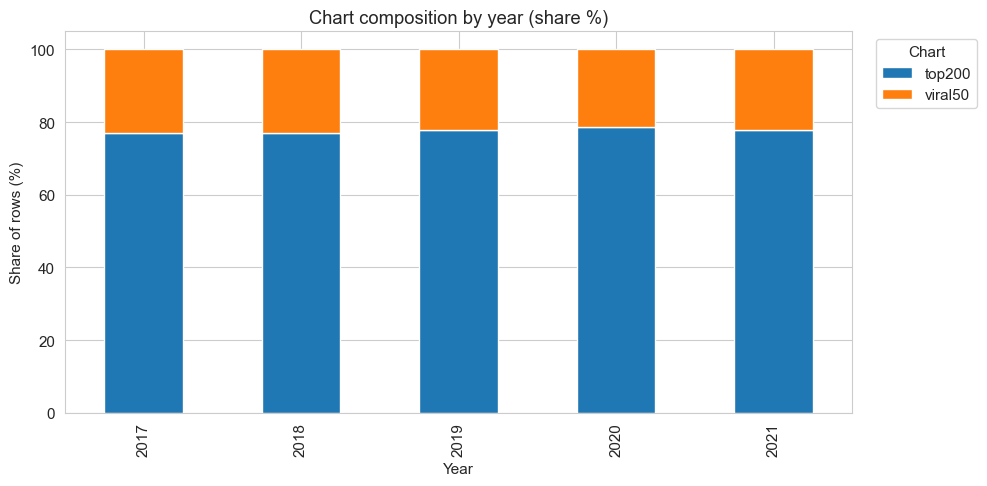

In [9]:
# Chart composition
chart_mix_df = con.execute("""
SELECT
    chart,
    COUNT(*) AS row_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_rows
FROM spotify_full
GROUP BY chart
ORDER BY row_count DESC;
""").df()

display(chart_mix_df)

global_share_df = con.execute("""
SELECT
    CASE WHEN LOWER(region) = 'global' THEN 'global' ELSE 'local' END AS scope,
    COUNT(*) AS row_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_rows
FROM spotify_full
GROUP BY 1
ORDER BY row_count DESC;
""").df()

print("Global vs local row share:")
display(global_share_df)

chart_mix_by_year_df = con.execute("""
WITH y AS (
    SELECT
        CASE
            WHEN TRY_CAST(year AS INTEGER) IS NOT NULL THEN TRY_CAST(year AS INTEGER)
            ELSE EXTRACT(YEAR FROM TRY_CAST(date AS DATE))::INTEGER
        END AS year_val,
        chart
    FROM spotify_full
)
SELECT
    year_val AS year,
    chart,
    COUNT(*) AS row_count
FROM y
WHERE year_val IS NOT NULL
GROUP BY 1,2
ORDER BY 1,2;
""").df()

chart_mix_year_pivot = chart_mix_by_year_df.pivot(index="year", columns="chart", values="row_count").fillna(0).sort_index()
chart_mix_year_share = chart_mix_year_pivot.div(chart_mix_year_pivot.sum(axis=1), axis=0) * 100

print("Chart mix by year (row counts):")
display(chart_mix_year_pivot.astype(int))

ax = chart_mix_year_share.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Chart composition by year (share %)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of rows (%)")
plt.legend(title="Chart", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2.2 Missing Values — Rates, Patterns, and Structural Sources

In [10]:
null_rows = []
for col in schema_df["column_name"].tolist():
    # Quote identifiers safely for DuckDB
    col_quoted = f'"{col}"'
    q = f"""SELECT '{col}' AS column_name,
                    AVG(CASE WHEN {col_quoted} IS NULL THEN 1.0 ELSE 0.0 END) AS null_rate
             FROM spotify_full"""
    null_rows.append(con.execute(q).df())

null_df = pd.concat(null_rows, ignore_index=True).sort_values("null_rate", ascending=False)
print("\nMissingness (top 15 by null rate):")
display(null_df.head(15))


Missingness (top 15 by null rate):


,column_name,null_rate
8,streams,0.223590
45,index,0.193528
44,cultural_top5_targets,0.193528
43,cultural_distance_count,0.193528
42,cultural_distance_max,0.193528
41,cultural_distance_min,0.193528
40,cultural_distance_median,0.193528
39,cultural_distance_mean,0.193528
33,country_population,0.034378
38,country_driving_side,0.034378


In [11]:
# Count entries with 0 or NULL streams
stream_quality = con.execute("""
    SELECT
        COUNT(*)                                                          AS total_rows,
        SUM(CASE WHEN streams IS NULL THEN 1 ELSE 0 END)                 AS null_streams,
        SUM(CASE WHEN streams IS NULL
                  OR TRY_CAST(streams AS DOUBLE) = 0 THEN 1 ELSE 0 END)  AS null_or_zero_streams
    FROM spotify_full

""").df()

total = stream_quality["total_rows"][0]
null_s  = stream_quality["null_streams"][0]
valid_s = total-null_s

print("═" * 50)
print("  STREAMS — NULL / ZERO ENTRY COUNT")
print("═" * 50)
print(f"  Total rows          : {total:>12,} ({total/total*100:.2f}%)")
print(f"  NULL streams        : {null_s:>12,}  ({null_s/total*100:.2f}%)")
print(f"Total valid stream    : {valid_s:> 12,} ({valid_s/total*100:.2f}%)")

print("═" * 50)


══════════════════════════════════════════════════
  STREAMS — NULL / ZERO ENTRY COUNT
══════════════════════════════════════════════════
  Total rows          :   26,174,269 (100.00%)
  NULL streams        :  5,852,308.0  (22.36%)
Total valid stream    :  20,321,961.0 (77.64%)
══════════════════════════════════════════════════


In [12]:
# Count entries with zero missing values (complete rows)
schema_df = con.execute("DESCRIBE spotify_full").df()
all_cols  = schema_df["column_name"].tolist()

# Build a CASE expression that counts NULLs across all columns per row
null_count_expr = " + ".join(
    [f"CASE WHEN \"{c}\" IS NULL THEN 1 ELSE 0 END" for c in all_cols]
)

completeness = con.execute(f"""
    SELECT
        COUNT(*)                                                      AS total_rows,
        SUM(CASE WHEN ({null_count_expr}) = 0 THEN 1 ELSE 0 END)     AS complete_rows,
        SUM(CASE WHEN ({null_count_expr}) > 0 THEN 1 ELSE 0 END)     AS rows_with_any_null,
        AVG(CASE WHEN ({null_count_expr}) = 0 THEN 1.0 ELSE 0.0 END) AS complete_rate
    FROM spotify_full
""").df()

total    = int(completeness["total_rows"][0])
complete = int(completeness["complete_rows"][0])
any_null = int(completeness["rows_with_any_null"][0])
rate     = float(completeness["complete_rate"][0])

print("═" * 55)
print("  ROW COMPLETENESS — zero missing values")
print("═" * 55)
print(f"  Total rows              : {total:>12,}")
print(f"  Complete rows (0 nulls) : {complete:>12,}  ({rate*100:.2f}%)")
print(f"  Rows with ≥1 null       : {any_null:>12,}  ({(1-rate)*100:.2f}%)")
print("═" * 55)

# Breakdown: how many nulls per row (distribution)
print("\n── Distribution of null-count-per-row ────────────────────────")
null_dist = con.execute(f"""
    SELECT
        ({null_count_expr}) AS n_nulls_in_row,
        COUNT(*)             AS n_rows
    FROM spotify_full
    GROUP BY n_nulls_in_row
    ORDER BY n_nulls_in_row
""").df()
display(null_dist)

═══════════════════════════════════════════════════════
  ROW COMPLETENESS — zero missing values
═══════════════════════════════════════════════════════
  Total rows              :   26,174,269
  Complete rows (0 nulls) :   16,423,650  (62.75%)
  Rows with ≥1 null       :    9,750,619  (37.25%)
═══════════════════════════════════════════════════════

── Distribution of null-count-per-row ────────────────────────


,n_nulls_in_row,n_rows
0,0,16423650
1,1,4428366
2,2,2601
3,3,4
4,7,3159976
5,8,962274
6,9,554
7,14,719359
8,15,173128
9,16,106


Integrated country diagnostics (top 25 by missing days):


,region,first_seen,last_seen,chart_rows,active_days,expected_days,missing_days,missing_days_pct,avg_streams,median_streams,total_streams
69,South Korea,2021-02-01,2021-12-31,76276,334,1826,1492,81.71,2687.430431,1826.0,1.600042e+08
66,Russia,2020-07-14,2021-12-31,126837,536,1826,1290,70.65,21099.099929,16537.5,2.124933e+09
65,Ukraine,2020-07-14,2021-12-31,127544,536,1826,1290,70.65,4333.549126,3432.0,4.366094e+08
55,India,2019-02-26,2021-12-31,253036,1040,1826,786,43.04,47457.710627,39744.0,9.554756e+09
58,Saudi Arabia,2018-11-19,2021-12-31,231649,1136,1826,690,37.79,3254.551647,2419.0,5.693740e+08
62,Morocco,2018-11-19,2021-12-31,191537,1136,1826,690,37.79,3088.643339,2133.0,4.164541e+08
64,Egypt,2018-11-19,2021-12-31,180469,1136,1826,690,37.79,2551.200398,1936.0,3.157468e+08
60,United Arab Emirates,2018-11-15,2021-12-31,198944,1140,1826,686,37.57,2147.140823,1649.0,3.050035e+08
52,Vietnam,2018-03-14,2021-12-31,312426,1389,1826,437,23.93,5695.451309,4076.0,1.387566e+09
50,Israel,2018-03-14,2021-12-31,330046,1389,1826,437,23.93,4703.704607,3805.0,1.230541e+09


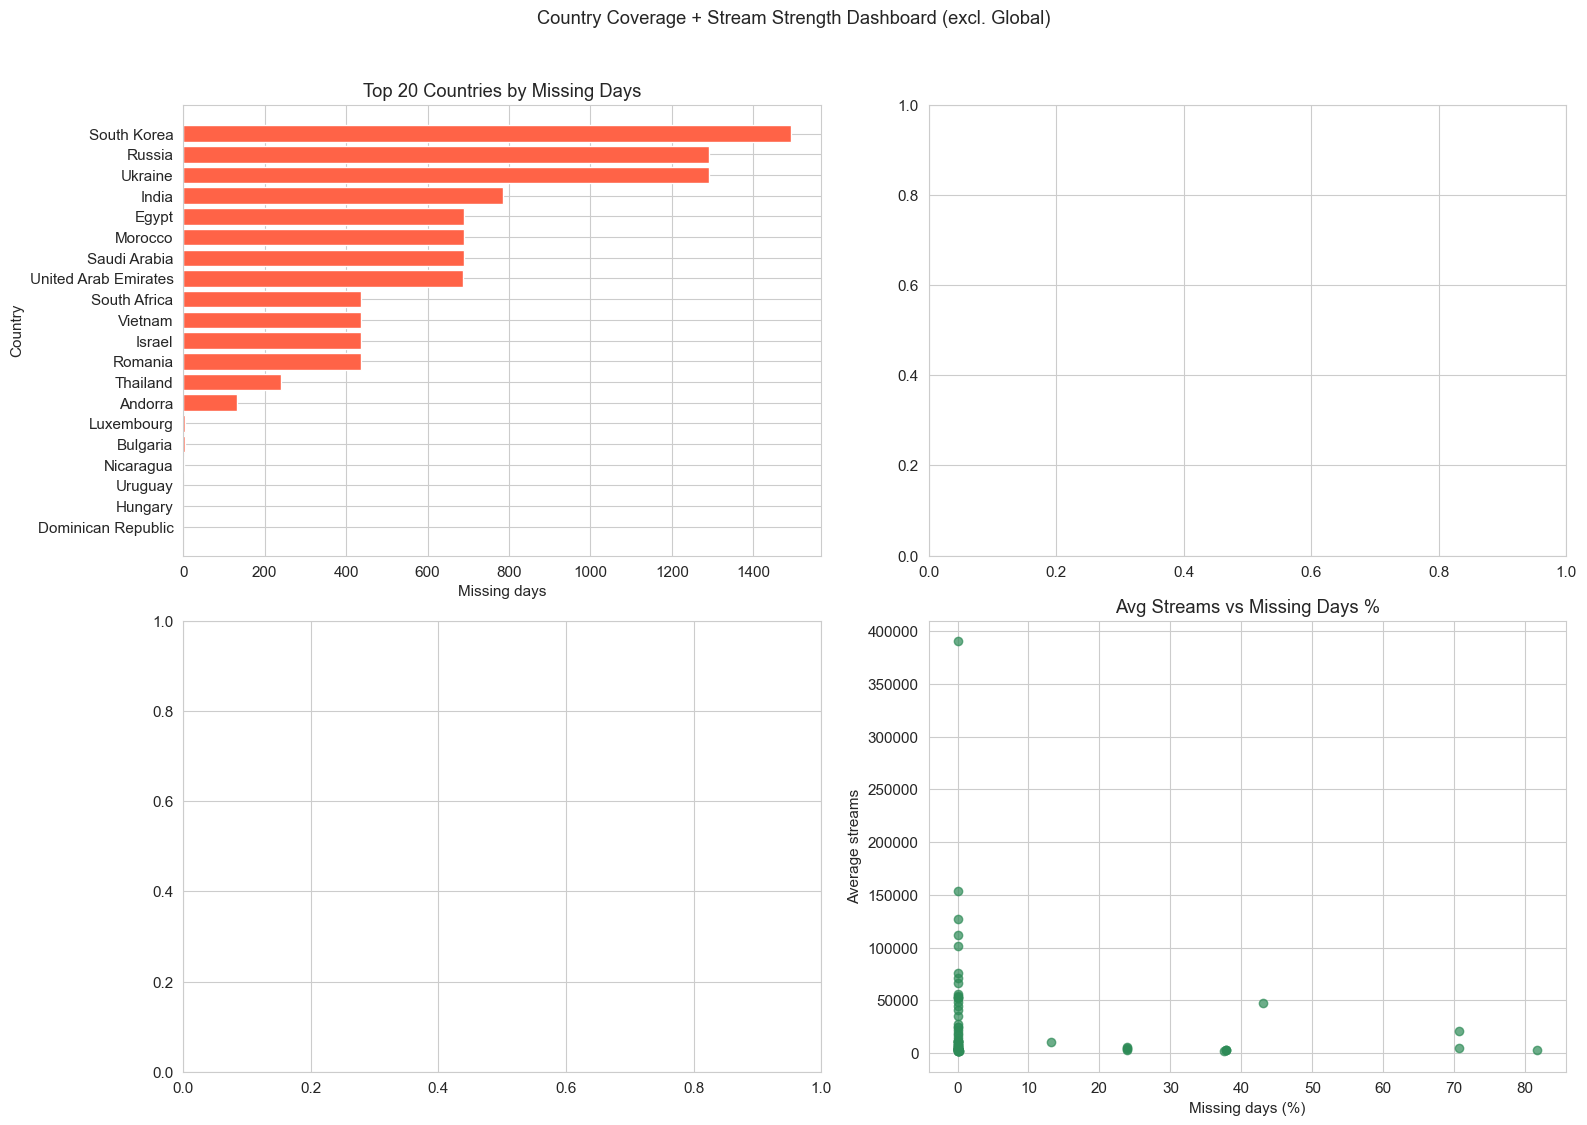

In [13]:
coverage_by_country_df = con.execute("""
WITH base AS (
    SELECT
        region,
        COALESCE(
            TRY_CAST(date AS DATE),
            CASE
                WHEN TRY_CAST(year AS INTEGER) IS NOT NULL THEN MAKE_DATE(TRY_CAST(year AS INTEGER), 1, 1)
                ELSE NULL
            END
        ) AS event_date
    FROM spotify_full
    WHERE region IS NOT NULL
)
SELECT
    region,
    COUNT(*) AS chart_rows,
    COUNT(DISTINCT event_date) AS active_days,
    MIN(event_date) AS first_seen,
    MAX(event_date) AS last_seen
FROM base
WHERE event_date IS NOT NULL
GROUP BY region
ORDER BY chart_rows DESC;
""").df()
# 3.2.1 Integrated country diagnostics table + dashboard
country_stream_stats_df = con.execute("""
SELECT
    region,
    COUNT(*) AS n_entries,
    AVG(TRY_CAST(streams AS DOUBLE)) AS avg_streams,
    MEDIAN(TRY_CAST(streams AS DOUBLE)) AS median_streams,
    MAX(TRY_CAST(streams AS BIGINT)) AS max_streams,
    SUM(TRY_CAST(streams AS BIGINT)) AS total_streams
FROM spotify_full
WHERE streams IS NOT NULL
  AND track_id IS NOT NULL
  AND region IS NOT NULL
GROUP BY region;
""").df()

missing_days_by_country_df = con.execute("""
WITH date_bounds AS (
    SELECT
        MIN(COALESCE(
            TRY_CAST(date AS DATE),
            CASE WHEN TRY_CAST(year AS INTEGER) IS NOT NULL THEN MAKE_DATE(TRY_CAST(year AS INTEGER), 1, 1) END
        )) AS min_date,
        MAX(COALESCE(
            TRY_CAST(date AS DATE),
            CASE WHEN TRY_CAST(year AS INTEGER) IS NOT NULL THEN MAKE_DATE(TRY_CAST(year AS INTEGER), 1, 1) END
        )) AS max_date
    FROM spotify_full
),
country_activity AS (
    SELECT
        region,
        COUNT(DISTINCT COALESCE(
            TRY_CAST(date AS DATE),
            CASE WHEN TRY_CAST(year AS INTEGER) IS NOT NULL THEN MAKE_DATE(TRY_CAST(year AS INTEGER), 1, 1) END
        )) AS active_days
    FROM spotify_full
    WHERE region IS NOT NULL
    GROUP BY region
)
SELECT
    ca.region,
    db.min_date,
    db.max_date,
    DATE_DIFF('day', db.min_date, db.max_date) + 1 AS expected_days,
    ca.active_days,
    (DATE_DIFF('day', db.min_date, db.max_date) + 1) - ca.active_days AS missing_days,
    ROUND(
        100.0 * ((DATE_DIFF('day', db.min_date, db.max_date) + 1) - ca.active_days)
        / (DATE_DIFF('day', db.min_date, db.max_date) + 1),
        2
    ) AS missing_days_pct
FROM country_activity ca
CROSS JOIN date_bounds db;
""").df()

country_diagnostics_df = (
    coverage_by_country_df
    .merge(missing_days_by_country_df[["region", "expected_days", "missing_days", "missing_days_pct"]], on="region", how="left")
    .merge(country_stream_stats_df, on="region", how="left")
)

# Exclude global for country-comparison views
country_diagnostics_no_global_df = country_diagnostics_df[
    country_diagnostics_df["region"].str.lower() != "global"
].copy()

# Neat summary table (most relevant fields)
country_diagnostics_display_df = country_diagnostics_no_global_df[[
    "region", "first_seen", "last_seen", "chart_rows", "active_days", "expected_days", "missing_days", "missing_days_pct",
    "avg_streams", "median_streams", "total_streams"
]].sort_values(["missing_days", "avg_streams"], ascending=[False, False])

print("Integrated country diagnostics (top 25 by missing days):")
display(country_diagnostics_display_df.head(25))

# ---- Graph dashboard ----
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) Missing days (top 20)
plot_missing = country_diagnostics_no_global_df.sort_values("missing_days", ascending=False).head(20)
axes[0, 0].barh(plot_missing["region"][::-1], plot_missing["missing_days"][::-1], color="tomato")
axes[0, 0].set_title("Top 20 Countries by Missing Days")
axes[0, 0].set_xlabel("Missing days")
axes[0, 0].set_ylabel("Country")

# 2) Average streams (top 20)
'''plot_avg = country_diagnostics_no_global_df.sort_values("avg_streams", ascending=False).head(20)
axes[0, 1].barh(plot_avg["region"][::-1], plot_avg["avg_streams"][::-1], color="steelblue")
axes[0, 1].set_title("Top 20 Countries by Average Streams")
axes[0, 1].set_xlabel("Average streams")
axes[0, 1].set_ylabel("Country")

# 3) Median streams (top 20)
plot_median = country_diagnostics_no_global_df.sort_values("median_streams", ascending=False).head(20)
axes[1, 0].barh(plot_median["region"][::-1], plot_median["median_streams"][::-1], color="salmon")
axes[1, 0].set_title("Top 20 Countries by Median Streams")
axes[1, 0].set_xlabel("Median streams")
axes[1, 0].set_ylabel("Country")
'''
# 4) Data completeness vs stream strength
axes[1, 1].scatter(
    country_diagnostics_no_global_df["missing_days_pct"],
    country_diagnostics_no_global_df["avg_streams"],
    alpha=0.7,
    color="seagreen"
)
axes[1, 1].set_title("Avg Streams vs Missing Days %")
axes[1, 1].set_xlabel("Missing days (%)")
axes[1, 1].set_ylabel("Average streams")

plt.suptitle("Country Coverage + Stream Strength Dashboard (excl. Global)", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# One sample entry per distinct null-count group — displayed side by side 
# Collect one sample row per group, then concatenate into a wide comparison table.

samples = {}

for n_nulls in null_dist["n_nulls_in_row"].tolist():
    n_rows = int(null_dist.loc[null_dist["n_nulls_in_row"] == n_nulls, "n_rows"].values[0])

    row = con.execute(f"""
        SELECT *
        FROM spotify_full
        WHERE ({null_count_expr}) = {n_nulls}
        LIMIT 1
    """).df().iloc[0]

    col_label = f"{n_nulls} nulls\n({n_rows:,} rows)"
    samples[col_label] = row

# Build wide DataFrame: rows = columns of spotify_full, columns = null-count groups
wide = pd.DataFrame(samples)

# Highlight null cells in red
def highlight_nulls(df):
    return df.map(lambda v: "background-color: #ffcccc; color: #cc0000" if pd.isna(v) else "")

display(
    wide.style
    .apply(highlight_nulls, axis=None)
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "11px"), ("text-align", "center"), ("white-space", "pre-wrap")]},
        {"selector": "td", "props": [("font-size", "10px"), ("max-width", "160px"),
                                      ("overflow", "hidden"), ("text-overflow", "ellipsis"),
                                      ("white-space", "nowrap")]},
    ])
    .set_caption("Sample entry per null-count group — red cells are NULL")
)


,"0 nulls (16,423,650 rows)","1 nulls (4,428,366 rows)","2 nulls (2,601 rows)",3 nulls (4 rows),"7 nulls (3,159,976 rows)","8 nulls (962,274 rows)",9 nulls (554 rows),"14 nulls (719,359 rows)","15 nulls (173,128 rows)",16 nulls (106 rows),"19 nulls (2,597 rows)","20 nulls (251,608 rows)",26 nulls (353 rows),"27 nulls (42,472 rows)",33 nulls (90 rows),"34 nulls (7,131 rows)"
title,Chantaje (feat. Maluma),Pongámonos De Acuerdo,Aoyama Bochi,None,Reggaetón Lento (Bailemos),Praying,When I Fall In Love,Closer,Back to You (feat. Bebe Rexha & Digital Farm Animals),Free From Boundaries,Año Nuevo 2017,Pal Matri (feat. Hayro DJ),One Love Manchester - Live from One Love Manchester,Love Falls Down,One Love Manchester - Live from One Love Manchester,Cely ten zbytek tebe
rank,1,118,47,38,1,38,50,1,1,9,178,38,179,22,120,47
date,2017-01-01,2017-01-01,2017-08-03,2019-07-15,2017-01-01,2017-08-02,2017-08-10,2017-01-01,2017-08-01,2017-01-03,2017-01-28,2017-09-05,2017-06-05,2017-03-06,2017-06-05,2017-03-07
artist,Shakira,Julión Álvarez y su Norteño Banda,Saeko Seki,Nissy,CNCO,Kesha,Ofelia Marsh,"The Chainsmokers, Halsey",Louis Tomlinson,Pernilla Mayer,DJ Luigi,DJ Krlos Berrospi,Various Artists,Poppy Ajudha,Various Artists,Mnaga A Zdorp
url,https://open.spotify.com/track/6mICuAdrwEjh6Y6lroV2Kg,https://open.spotify.com/track/3FhuPkzBM6VMLvc6rcer8v,https://open.spotify.com/track/6aLLf5UU8GivpvjLxdOog1,https://open.spotify.com/track/4cP6KmNvTFkLHZo6fVJq0c,https://open.spotify.com/track/3AEZUABDXNtecAOSC1qTfo,https://open.spotify.com/track/79NlESqzFSW0hdBWgls4FX,https://open.spotify.com/track/3RTSNE39EhMQkzwKwEu5v4,https://open.spotify.com/track/7BKLCZ1jbUBVqRi2FVlTVw,https://open.spotify.com/track/7F9vK8hNFMml4GtHsaXui6,https://open.spotify.com/track/2BA9lxm5WcM1Ek98E70gav,https://open.spotify.com/track/4IjwENtDPy4KqpnU9iBBca,https://open.spotify.com/track/3aiLkdJbT9V51m2GAqfn4r,https://open.spotify.com/track/3uMIfxV8q5tPTWzJh8s6Mk,https://open.spotify.com/track/5X5XhvErlZwcy9Mj0O2aVV,https://open.spotify.com/track/3uMIfxV8q5tPTWzJh8s6Mk,https://open.spotify.com/track/20gqsExg8aH2hJVA6Ph6SV
region,Argentina,Mexico,Singapore,Japan,Costa Rica,Costa Rica,United Kingdom,Czech Republic,Czech Republic,Czech Republic,Peru,Peru,United Kingdom,United Kingdom,Czech Republic,Czech Republic
chart,top200,top200,viral50,viral50,top200,viral50,viral50,top200,viral50,viral50,top200,viral50,top200,viral50,top200,viral50
trend,SAME_POSITION,MOVE_UP,NEW_ENTRY,NEW_ENTRY,SAME_POSITION,MOVE_UP,NEW_ENTRY,SAME_POSITION,SAME_POSITION,NEW_ENTRY,NEW_ENTRY,NEW_ENTRY,NEW_ENTRY,NEW_ENTRY,NEW_ENTRY,NEW_ENTRY
streams,253019.0,45427.0,None,None,20171.0,None,None,6406.0,None,None,4351.0,None,40030.0,None,1660.0,None
track_id,6mICuAdrwEjh6Y6lroV2Kg,3FhuPkzBM6VMLvc6rcer8v,6aLLf5UU8GivpvjLxdOog1,4cP6KmNvTFkLHZo6fVJq0c,3AEZUABDXNtecAOSC1qTfo,79NlESqzFSW0hdBWgls4FX,3RTSNE39EhMQkzwKwEu5v4,7BKLCZ1jbUBVqRi2FVlTVw,7F9vK8hNFMml4GtHsaXui6,2BA9lxm5WcM1Ek98E70gav,None,None,None,None,None,None


**Interpretation — Missing Values:** The analysis reveals two structurally distinct sources of missingness. Stream counts are missing for 22.4% of rows (5,852,308 entries), and this gap appears concentrated in Viral 50 entries and the earlier years of the dataset — meaning the missingness is not random but linked to chart type and time period. Simply dropping these rows would systematically remove a specific segment of chart activity, introducing selection bias into any downstream analysis.

Cultural distance and Hofstede index values are missing for approximately 19.4% of rows. This corresponds to countries for which no cultural dimension scores exist in the underlying reference database — the missingness is structural and tied to identifiable countries. Rows belonging to these countries can be defined as an explicit exclusion from cultural distance analyses, provided this decision is documented and applied consistently.

The row completeness summary shows that 62.8% of rows are fully complete across all 46 columns. The remaining rows have gaps concentrated in the stream and cultural distance columns; very few rows are missing values from multiple unrelated columns simultaneously, which suggests the missing data patterns are tractable rather than pervasive.

## 2.3 Duplicate Records

In [15]:
# Check for repeated chart-event keys rather than full-row exact duplicates
print("  DUPLICATE KEY CHECK — (track_id, region, date, chart)")
print("═" * 60)

# 1. Total rows vs distinct chart-event keys
totals = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT (track_id, region, date, chart)) AS distinct_combinations
    FROM spotify_full
    WHERE streams IS NOT NULL
      AND track_id IS NOT NULL
""").df()

total     = int(totals["total_rows"][0])
distinct  = int(totals["distinct_combinations"][0])
dupes     = total - distinct

print(f"\n  Total rows (excl. NULL streams/track_id) : {total:>12,}")
print(f"  Distinct chart-event keys                : {distinct:>12,}")
print(f"  Extra rows beyond unique keys            : {dupes:>12,}  ({dupes/total*100:.2f}%)")

# 2. Top 20 most repeated keys
print("\n── Top 20 most repeated (track_id, region, date, chart) keys ──")
top_dupes = con.execute("""
    SELECT
        track_id,
        region,
        date,
        chart,
        COUNT(*) AS n_entries,
        MIN(TRY_CAST(streams AS BIGINT)) AS streams_min,
        MAX(TRY_CAST(streams AS BIGINT)) AS streams_max
    FROM spotify_full
    WHERE streams IS NOT NULL
      AND track_id IS NOT NULL
    GROUP BY track_id, region, date, chart
    HAVING COUNT(*) > 1
    ORDER BY n_entries DESC
""").df()

if top_dupes.empty:
    print("No repeated chart-event keys found!")
else:
    print(f"{len(top_dupes):,} repeated key groups found (showing top 20)")
    display(top_dupes)

# 3. Are stream values identical across repeated keys, or do they differ?
print("\n── Do repeated key groups have conflicting stream values? ────────")
conflict_check = con.execute("""
    SELECT
        COUNT(*) AS groups_with_conflicting_streams
    FROM (
        SELECT track_id, region, date, chart
        FROM spotify_full
        WHERE streams IS NOT NULL
          AND track_id IS NOT NULL
        GROUP BY track_id, region, date, chart
        HAVING COUNT(*) > 1
          AND MIN(TRY_CAST(streams AS BIGINT)) != MAX(TRY_CAST(streams AS BIGINT))
    )
""").fetchone()[0]

if conflict_check == 0:
    print("All repeated key groups have identical stream values (safe to deduplicate by key).")
else:
    print(f"{conflict_check:,} repeated key groups have DIFFERENT stream values — inspect before dropping!")

  DUPLICATE KEY CHECK — (track_id, region, date, chart)
════════════════════════════════════════════════════════════

  Total rows (excl. NULL streams/track_id) :   20,318,921
  Distinct chart-event keys                :   20,318,864
  Extra rows beyond unique keys            :           57  (0.00%)

── Top 20 most repeated (track_id, region, date, chart) keys ──
57 repeated key groups found (showing top 20)


,track_id,region,date,chart,n_entries,streams_min,streams_max
0,4Rg9TAzx7mq7MEmEFdQzIb,Belgium,2017-09-06,top200,2,5147,5147
1,4hGyLmElEHdBf29ubQ61Yq,Peru,2017-10-05,top200,2,13329,13329
2,4hGyLmElEHdBf29ubQ61Yq,Peru,2017-10-10,top200,2,24820,24820
3,3JGE1pWIf4Z6JqjIz6f1F4,Austria,2017-09-01,top200,2,2627,2627
4,5RwZ97IdwhGxQWsvSXBokl,Paraguay,2017-09-01,top200,2,2117,2117
5,3al2hpm92xE0pBalqWQHdD,United States,2017-10-17,top200,2,172563,172563
6,6w40GgWhGts8g6779DPXR3,Israel,2018-03-20,top200,2,1006,1006
7,3JGE1pWIf4Z6JqjIz6f1F4,Germany,2017-09-06,top200,2,31926,31926
8,4Rg9TAzx7mq7MEmEFdQzIb,Belgium,2017-09-07,top200,2,4534,4534
9,5kFakScPV7ZWXStUSvQmxA,Taiwan,2017-09-26,top200,2,2628,2628



── Do repeated key groups have conflicting stream values? ────────
All repeated key groups have identical stream values (safe to deduplicate by key).


**Clarification:** This section checks for repeated chart-event keys using `(track_id, region, date, chart)`, not full-row exact duplicates across every column. A song-country-date-chart combination appearing twice means the same logical chart event was ingested more than once, even if an exact raw-row duplicate count elsewhere in the project is larger because it uses a different definition and filtering stage.

## 2.4 Structural Validation — Single Track Across Countries

In [16]:
TRACK_ID = "6mICuAdrwEjh6Y6lroV2Kg"

all_entries = con.execute(f"""
    SELECT title, date, track_id, region, chart, artist,
           TRY_CAST(streams AS BIGINT) AS streams,
           year
    FROM spotify_full
    WHERE track_id = '{TRACK_ID}'
      AND date = '2017-02-04'
    ORDER BY streams DESC
    LIMIT 10
""").df()

print(f"Total entries found for track, this is with the limit: {len(all_entries):,}")
display(all_entries)

Total entries found for track, this is with the limit: 10


,title,date,track_id,region,chart,artist,streams,year
0,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Global,top200,Shakira,2525024,2017
1,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Mexico,top200,Shakira,392920,2017
2,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,United States,top200,Shakira,335450,2017
3,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Spain,top200,Shakira,283435,2017
4,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Germany,top200,Shakira,184731,2017
5,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Argentina,top200,Shakira,179411,2017
6,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Brazil,top200,Shakira,152974,2017
7,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Chile,top200,Shakira,129493,2017
8,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,France,top200,Shakira,94284,2017
9,Chantaje (feat. Maluma),2017-02-04,6mICuAdrwEjh6Y6lroV2Kg,Netherlands,top200,Shakira,87131,2017


In [17]:
# Total streams across all countries (excluding global) 
total_streams = con.execute(f"""
    SELECT SUM(TRY_CAST(streams AS BIGINT)) AS total_streams
    FROM spotify_full
    WHERE track_id = '{TRACK_ID}'
      AND date = '2017-02-04'
      AND LOWER(region) != 'global'
""").fetchone()[0]

print(f"Total streams for track '{TRACK_ID}' on 2017-02-04 (excl. global): {total_streams:,}")

Total streams for track '6mICuAdrwEjh6Y6lroV2Kg' on 2017-02-04 (excl. global): 2,520,622


**Finding — The "Global" Region is a Derived Aggregate:** The query above confirms that the Global stream total for this track on this date (2,520,622) is consistent with the sum of all country-level non-global entries for the same track and date. The Global chart entry is therefore not an independent market observation but a derived summation. Including Global rows alongside country-level rows in any analysis that measures geographic reach or market-level behaviour would result in double-counting and artificially inflate apparent stream volumes. The Global region must be **excluded from all country-level analyses**; it may be retained only where aggregate totals are explicitly the object of interest.

With this confirmed, the remaining quality question is how the primary quantitative variable — daily stream counts — is distributed, and what transformation, if any, is required before it can serve as a modeling target.

## 2.5 Distribution of Daily Stream Counts

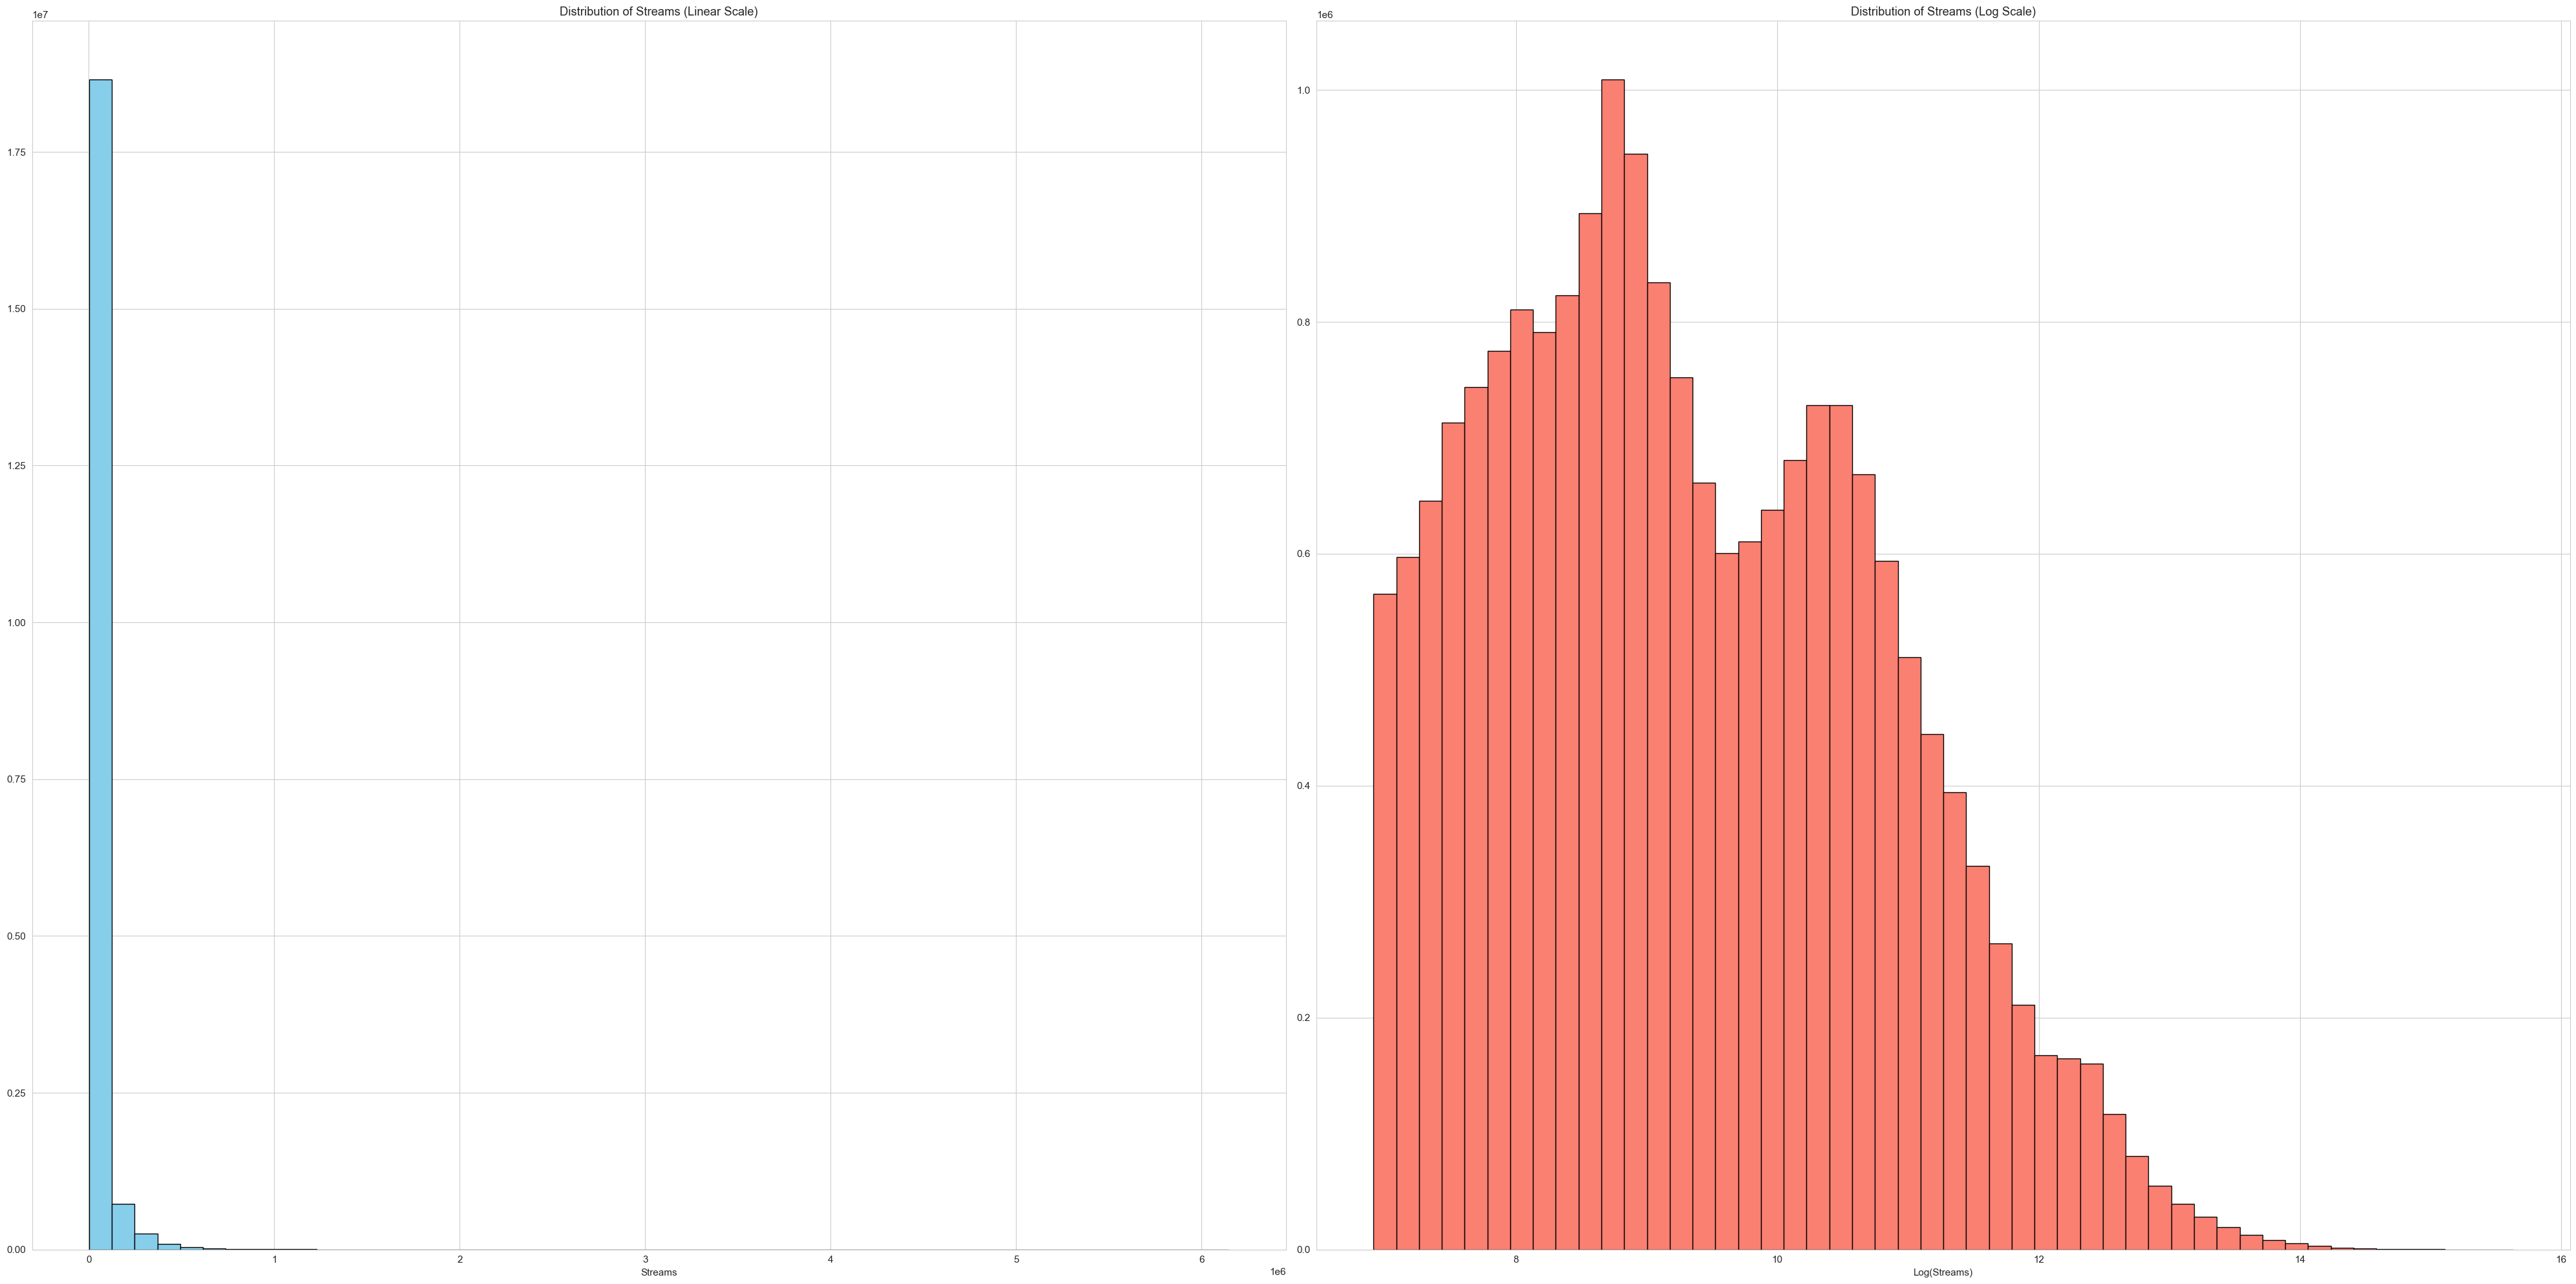

In [18]:
# Sample the data for visualization (as the dataset is too big for full pandas plotting)
sample_df = con.execute("SELECT TRY_CAST(streams AS DOUBLE) as streams FROM spotify_full WHERE streams IS NOT NULL AND LOWER (region) != 'global' USING SAMPLE 26000000").df()

plt.figure(figsize=(40, 20))

# Plot 1: Standard Distribution
plt.subplot(1, 2, 1)
plt.hist(sample_df['streams'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Streams (Linear Scale)")
plt.xlabel("Streams")

# Plot 2: Log Distribution 
plt.subplot(1, 2, 2)
plt.hist(np.log1p(sample_df['streams']), bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Streams (Log Scale)")
plt.xlabel("Log(Streams)")

plt.tight_layout()
plt.show()

**Interpretation — Stream Distribution:** The linear-scale histogram confirms strong right-skewness: the bulk of chart entries cluster between roughly 1,000 and 200,000 daily streams, reflecting typical performance in small-to-medium markets, while the tail extends beyond 6 million daily streams for the largest global artists in the highest-volume markets. The contrast is not marginal — the gap between the median and the 99th percentile spans multiple orders of magnitude.

The log₁₀ panel is the more informative of the two. It reveals an approximately bell-shaped distribution, consistent with a log-normal generating process. This supports treating **log(streams) as the regression target**: the transformation compresses the extreme right tail, reduces heteroscedasticity, and aligns with the multiplicative nature of viral diffusion and cumulative listening behaviour that underlies streaming dynamics.

**Section 7 Wrap-Up:** Section 7 has established the dataset's structure and identified all critical data quality issues. The cleaning decisions — excluding the Global region, handling non-random missingness in streams, dropping the 57 duplicates, and applying a log transformation to streams — are now fixed and will be applied consistently in all subsequent analyses and modeling steps. Section 8 turns from quality assessment to substantive analysis, examining the patterns across countries, artists, and individual songs that will drive feature engineering.

── Stream value percentiles (full dataset) ──────────────────


,p50,p90,p95,p99,p999,max_streams
0,9201.0,81240.0,141359.0,355946.44,909675.222,6146233.0



── Top 20 highest-stream entries ────────────────────────────


,date,title,artist,region,chart,rank,streams,year
0,2021-09-03,Girls Want Girls (with Lil Baby),Drake,United States,top200,1,6146233,2021
1,2021-01-12,drivers license,Olivia Rodrigo,United States,top200,1,6145601,2021
2,2021-09-03,Champagne Poetry,Drake,United States,top200,2,5953619,2021
3,2018-06-29,Nonstop,Drake,United States,top200,1,5749019,2018
4,2021-01-13,drivers license,Olivia Rodrigo,United States,top200,1,5723851,2021
5,2021-01-11,drivers license,Olivia Rodrigo,United States,top200,1,5688246,2021
6,2021-09-03,Fair Trade (with Travis Scott),Drake,United States,top200,3,5616734,2021
7,2021-10-15,Easy On Me,Adele,United States,top200,1,5435431,2021
8,2021-01-14,drivers license,Olivia Rodrigo,United States,top200,1,5271136,2021
9,2018-06-29,Survival,Drake,United States,top200,2,5219711,2018



── Entries above stream thresholds ──────────────────────────
  streams >    6,000,000 :        2 entries
  streams >    3,000,000 :      275 entries
  streams >    1,000,000 :   15,037 entries
  streams >      500,000 :   94,398 entries

── Histogram of streams above the 99th percentile ──────────


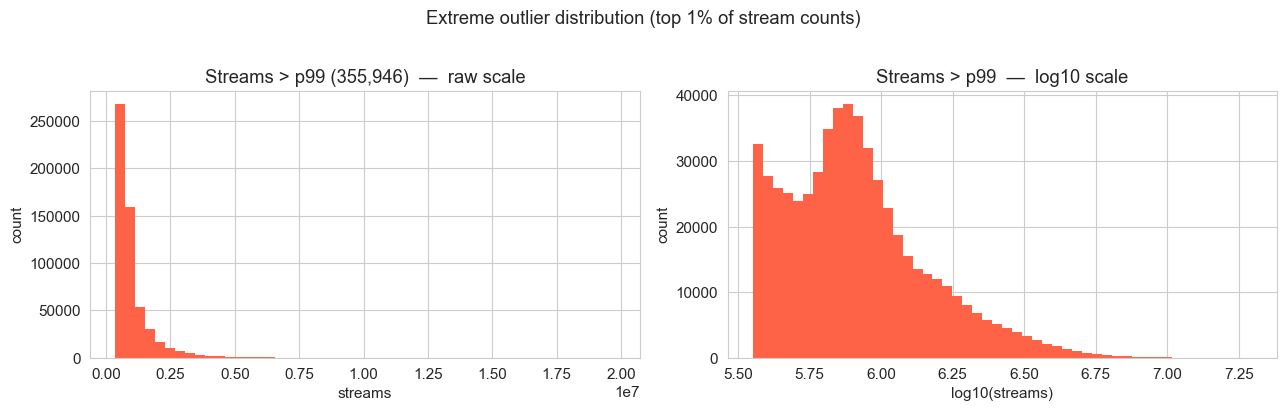


Note: The bulk of data sits around 9,201 streams (median).
The very top entries reach 6,146,233 streams — ~668× the median.


In [19]:
# 1. Key percentiles to see where the tail starts
print("── Stream value percentiles (full dataset) ──────────────────")
pcts = con.execute("""
    SELECT
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY TRY_CAST(streams AS DOUBLE)) AS p50,
        PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY TRY_CAST(streams AS DOUBLE)) AS p90,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY TRY_CAST(streams AS DOUBLE)) AS p95,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY TRY_CAST(streams AS DOUBLE)) AS p99,
        PERCENTILE_CONT(0.999) WITHIN GROUP (ORDER BY TRY_CAST(streams AS DOUBLE)) AS p999,
        MAX(TRY_CAST(streams AS DOUBLE)) AS max_streams
    FROM spotify_full
    WHERE streams IS NOT NULL AND LOWER(region) != 'global'
""").df()
display(pcts)

# 2. Top 20 individual entries by stream count
print("\n── Top 20 highest-stream entries ────────────────────────────")
top20 = con.execute("""
    SELECT
        date,
        title,
        artist,
        region,
        chart,
        TRY_CAST(rank    AS INTEGER) AS rank,
        TRY_CAST(streams AS BIGINT)  AS streams,
        year
    FROM spotify_full
    WHERE streams IS NOT NULL AND LOWER(region) != 'global'
    ORDER BY TRY_CAST(streams AS DOUBLE) DESC
    LIMIT 20
""").df()
display(top20)

# 3. How many entries exceed common "suspicious" thresholds?
print("\n── Entries above stream thresholds ──────────────────────────")
thresholds = [6_000_000, 3_000_000, 1_000_000, 500_000]
for t in thresholds:
    n = con.execute(f"""
        SELECT COUNT(*) FROM spotify_full
        WHERE TRY_CAST(streams AS DOUBLE) > {t} AND LOWER(region) != 'global'
    """).fetchone()[0]
    print(f"  streams > {t:>12,} : {n:>8,} entries")

# 4. Distribution of the top 1% visually
print("\n── Histogram of streams above the 99th percentile ──────────")
p99_val = float(pcts["p99"].iloc[0])
top1pct = con.execute(f"""
    SELECT TRY_CAST(streams AS DOUBLE) AS streams
    FROM spotify_full
    WHERE TRY_CAST(streams AS DOUBLE) > {p99_val}
      AND streams IS NOT NULL 
""").df()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(top1pct["streams"], bins=50, color="tomato", edgecolor="none")
axes[0].set_title(f"Streams > p99 ({p99_val:,.0f})  —  raw scale")
axes[0].set_xlabel("streams")
axes[0].set_ylabel("count")

axes[1].hist(np.log10(top1pct["streams"]), bins=50, color="tomato", edgecolor="none")
axes[1].set_title("Streams > p99  —  log10 scale")
axes[1].set_xlabel("log10(streams)")
axes[1].set_ylabel("count")

plt.suptitle("Extreme outlier distribution (top 1% of stream counts)", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nNote: The bulk of data sits around {float(pcts['p50'].iloc[0]):,.0f} streams (median).")
print(f"The very top entries reach {int(pcts['max_streams'].iloc[0]):,} streams — "
      f"~{int(pcts['max_streams'].iloc[0]) / float(pcts['p50'].iloc[0]):.0f}× the median.")

## 2.6 Data Type Issues — VARCHAR Casting Registry

In [20]:
# ── 7.6  Numeric columns stored as VARCHAR — casting registry + audit ────────
schema_df = con.execute("DESCRIBE spotify_full").df()
existing_cols = set(schema_df["column_name"].tolist())

# All columns that are semantically numeric but stored as VARCHAR
CAST_REGISTRY = [
    # (column,                  intended_type,  cast_expression,                           notes)
    ("streams",              "BIGINT",   "TRY_CAST(streams AS BIGINT)",              "Primary target; ~22.4% NULL (Viral 50 + early years)"),
    ("rank",                 "INTEGER",  "TRY_CAST(rank AS INTEGER)",                "Chart position 1–200 / 1–50"),
    ("af_danceability",      "DOUBLE",   "TRY_CAST(af_danceability AS DOUBLE)",      "Spotify audio feature [0, 1]"),
    ("af_energy",            "DOUBLE",   "TRY_CAST(af_energy AS DOUBLE)",            "Spotify audio feature [0, 1]"),
    ("af_valence",           "DOUBLE",   "TRY_CAST(af_valence AS DOUBLE)",           "Spotify audio feature [0, 1]"),
    ("af_tempo",             "DOUBLE",   "TRY_CAST(af_tempo AS DOUBLE)",             "Beats per minute (continuous)"),
    ("af_loudness",          "DOUBLE",   "TRY_CAST(af_loudness AS DOUBLE)",          "dB, typically −60 to 0"),
    ("af_acousticness",      "DOUBLE",   "TRY_CAST(af_acousticness AS DOUBLE)",      "Spotify audio feature [0, 1]"),
    ("af_speechiness",       "DOUBLE",   "TRY_CAST(af_speechiness AS DOUBLE)",       "Spotify audio feature [0, 1]; zero-inflated"),
    ("af_instrumentalness",  "DOUBLE",   "TRY_CAST(af_instrumentalness AS DOUBLE)",  "Spotify audio feature [0, 1]; zero-inflated"),
    ("af_liveness",          "DOUBLE",   "TRY_CAST(af_liveness AS DOUBLE)",          "Spotify audio feature [0, 1]"),
    ("popularity",           "INTEGER",  "TRY_CAST(popularity AS INTEGER)",          "Spotify popularity score [0, 100]"),
    ("duration_ms",          "BIGINT",   "TRY_CAST(duration_ms AS BIGINT)",          "Track duration in milliseconds"),
    ("af_key",               "INTEGER",  "TRY_CAST(af_key AS INTEGER)",              "Chromatic key [0–11]; CATEGORICAL — one-hot encode"),
    ("af_mode",              "INTEGER",  "TRY_CAST(af_mode AS INTEGER)",             "Binary: 1=major, 0=minor; CATEGORICAL"),
    ("af_time_signature",    "INTEGER",  "TRY_CAST(af_time_signature AS INTEGER)",   "Beats per bar (3 or 4 typically); CATEGORICAL"),
]

cast_df = pd.DataFrame(CAST_REGISTRY, columns=["column", "intended_type", "cast_expression", "notes"])
cast_df["stored_type"]       = cast_df["column"].map(schema_df.set_index("column_name")["column_type"].to_dict())
cast_df["in_dataset"]        = cast_df["column"].isin(existing_cols)
cast_df = cast_df[["column", "stored_type", "intended_type", "in_dataset", "cast_expression", "notes"]]

print("═" * 80)
print("  NUMERIC COLUMNS STORED AS VARCHAR — Full Casting Registry")
print("═" * 80)
display(cast_df)

# ── Cast-failure audit: % of rows where TRY_CAST returns NULL on a non-null value
print("\n── Cast-failure rates per column (% non-null rows that fail to parse) ────────")
failure_rows = []
for _, row in cast_df[cast_df["in_dataset"]].iterrows():
    col   = row["column"]
    cexpr = row["cast_expression"]
    q = f"""
        SELECT
            '{col}' AS column_name,
            COUNT(*) AS total_rows,
            SUM(CASE WHEN \"{col}\" IS NOT NULL
                      AND {cexpr} IS NULL
                 THEN 1 ELSE 0 END) AS cast_failures,
            ROUND(
                100.0 * SUM(CASE WHEN \"{col}\" IS NOT NULL AND {cexpr} IS NULL
                                 THEN 1 ELSE 0 END)
                / NULLIF(SUM(CASE WHEN \"{col}\" IS NOT NULL THEN 1 ELSE 0 END), 0),
            4) AS failure_pct
        FROM spotify_full
    """
    try:
        failure_rows.append(con.execute(q).df())
    except Exception as e:
        print(f"  Skipped {col}: {e}")

if failure_rows:
    failure_df = pd.concat(failure_rows, ignore_index=True).sort_values("failure_pct", ascending=False)
    display(failure_df)
    if failure_df["failure_pct"].max() == 0:
        print("\n  ✅  Zero cast failures — all non-null VARCHAR values parse cleanly to their intended numeric types.")
    else:
        bad = failure_df[failure_df["failure_pct"] > 0]
        print(f"\n  ⚠️  {len(bad)} column(s) have cast failures — investigate before modeling:")
        display(bad)

════════════════════════════════════════════════════════════════════════════════
  NUMERIC COLUMNS STORED AS VARCHAR — Full Casting Registry
════════════════════════════════════════════════════════════════════════════════


,column,stored_type,intended_type,in_dataset,cast_expression,notes
0,streams,VARCHAR,BIGINT,True,TRY_CAST(streams AS BIGINT),Primary target; ~22.4% NULL (Viral 50 + early ...
1,rank,VARCHAR,INTEGER,True,TRY_CAST(rank AS INTEGER),Chart position 1–200 / 1–50
2,af_danceability,VARCHAR,DOUBLE,True,TRY_CAST(af_danceability AS DOUBLE),"Spotify audio feature [0, 1]"
3,af_energy,VARCHAR,DOUBLE,True,TRY_CAST(af_energy AS DOUBLE),"Spotify audio feature [0, 1]"
4,af_valence,VARCHAR,DOUBLE,True,TRY_CAST(af_valence AS DOUBLE),"Spotify audio feature [0, 1]"
5,af_tempo,VARCHAR,DOUBLE,True,TRY_CAST(af_tempo AS DOUBLE),Beats per minute (continuous)
6,af_loudness,VARCHAR,DOUBLE,True,TRY_CAST(af_loudness AS DOUBLE),"dB, typically −60 to 0"
7,af_acousticness,VARCHAR,DOUBLE,True,TRY_CAST(af_acousticness AS DOUBLE),"Spotify audio feature [0, 1]"
8,af_speechiness,VARCHAR,DOUBLE,True,TRY_CAST(af_speechiness AS DOUBLE),"Spotify audio feature [0, 1]; zero-inflated"
9,af_instrumentalness,VARCHAR,DOUBLE,True,TRY_CAST(af_instrumentalness AS DOUBLE),"Spotify audio feature [0, 1]; zero-inflated"



── Cast-failure rates per column (% non-null rows that fail to parse) ────────


,column_name,total_rows,cast_failures,failure_pct
0,streams,26174269,0.0,0.0
1,rank,26174269,0.0,0.0
2,af_danceability,26174269,0.0,0.0
3,af_energy,26174269,0.0,0.0
4,af_valence,26174269,0.0,0.0
5,af_tempo,26174269,0.0,0.0
6,af_loudness,26174269,0.0,0.0
7,af_acousticness,26174269,0.0,0.0
8,af_speechiness,26174269,0.0,0.0
9,af_instrumentalness,26174269,0.0,0.0



  ✅  Zero cast failures — all non-null VARCHAR values parse cleanly to their intended numeric types.


**Interpretation — Numeric Fields as VARCHAR and Casting Strategy:**

The audit confirms that `TRY_CAST` produces zero parse failures across all affected columns — the values are syntactically correct numbers stored in string form. This is a schema artefact, not a data quality defect, and has no effect on analytical accuracy provided every query and preprocessing step applies the appropriate cast.

**Casting rules applied throughout this notebook:**

| Category | Rule |
|---|---|
| Stream counts, rank, duration, popularity | `TRY_CAST(... AS BIGINT)` or `INTEGER` — discrete counts |
| All `af_*` continuous features | `TRY_CAST(... AS DOUBLE)` — floating-point |
| `af_key`, `af_mode`, `af_time_signature` | Cast to `INTEGER` then **one-hot encode** — these are categorical, not ordinal |
| Scikit-learn pipeline | Casting is applied in the DuckDB sampling query; `sample_df` contains properly typed columns before any sklearn step |

`TRY_CAST` is used in preference to `CAST` everywhere because it returns `NULL` on failure rather than raising a runtime error, making queries robust to any residual edge-case values.

## 2.7 Data Quality Verdict — Keep / Drop / Impute Decisions

---

## 🏁 Data Quality Verdict

The quality checks in Section 7 (schema, missingness, duplicates, structural validation, stream distribution, and VARCHAR casting) collectively define the analytical sample used in all downstream analyses. The decisions below are applied consistently throughout this notebook and must be replicated in any feature engineering or modeling pipeline that follows.

---

### ✅ What We Keep

| Issue | Decision | Rationale |
|---|---|---|
| Top 200 rows with valid `streams` | **Keep** | Core modeling sample; stream values parse cleanly with zero cast failures. |
| Viral 50 rows with valid `streams` | **Keep** | Avoids selection bias toward only high-stream tracks; `chart` type is included as a model feature. |
| Rows with missing cultural distance (~19.4%) | **Keep with imputation flag** | Missingness is structural (countries absent from Hofstede database). Impute with continent-level median; add binary `cultural_distance_imputed` indicator. |
| All VARCHAR numeric columns | **Keep — cast on use** | Values are well-formed; `TRY_CAST` produces 0% failures. No data loss from casting. |
| `af_key`, `af_mode`, `af_time_signature` | **Keep as categoricals** | Semantically categorical; one-hot encode rather than treating raw integers as ordinal. |

---

### ❌ What We Drop

| Issue | Decision | Rationale |
|---|---|---|
| **Global region rows** | **Drop from country-level analyses** | Derived aggregate (sum of country entries). Including alongside country rows causes double-counting. |
| **57 exact duplicate rows** | **Drop** | All duplicates carry identical `streams` values — safe to remove without information loss. |
| **Rows with NULL `streams` (regression target)** | **Drop for modeling** | Cannot regress on a missing target. 22.4% of rows affected; missingness is non-random (concentrated in Viral 50 and pre-2018 data) — documented as a limitation. |

---

### 🔧 What We Impute

| Issue | Strategy | Rationale |
|---|---|---|
| Missing cultural distance / Hofstede features (~19.4%) | **Continent-level median imputation + indicator flag** | Country-specific structural gaps; dropping would eliminate entire markets from the model. |
| Missing audio features (sparse, tied to Viral 50) | **Global median imputation** | Gaps are small and not concentrated in any identifiable subset; median imputation introduces minimal bias. |

---

### ⚙️ Why These Decisions Matter for Modeling

- **Dropping Global rows** ensures geographic reach counts are based on independent market observations, not aggregated totals.
- **Log-transforming `streams`** is mandatory: the raw distribution spans five orders of magnitude and an MSE objective would collapse to fitting only the highest-volume outliers.
- **Casting VARCHAR numerics** is a non-negotiable prerequisite — DuckDB silently returns `NULL` from arithmetic on `VARCHAR` columns, producing incorrect aggregations if `TRY_CAST` is omitted.
- **One-hot encoding `af_key` and `af_mode`** avoids a false ordinal structure (key 11 is not musically “greater than” key 1).
- **Retaining imputed cultural distance rows** with an indicator preserves geographic diversity in the training set while allowing the model to down-weight imputed values if the indicator is included as a feature.

---
# Part III — Filtering and Clean Dataset Definition

## 3.1 Apply Filtering Decisions

Apply all data quality decisions from Section 2.7:
- Filter to Top 200 chart only (Viral 50 retained only for the `is_viral50_flag` feature)
- Exclude "Global" region (confirmed as derived aggregate in Section 2.4)
- Remove confirmed duplicate rows
- Drop rows where `track_id` is null
- Drop rows where `streams` is null (cannot compute target without chart data)

In [21]:
# ── 3.1 Create filtered clean view ──────────────────────────────────────────
con.execute("""
    CREATE OR REPLACE VIEW spotify_clean AS
    WITH deduplicated AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY track_id, region, date, chart
                   ORDER BY date
               ) AS rn
        FROM spotify_full
        WHERE track_id IS NOT NULL
          AND streams IS NOT NULL
          AND LOWER(region) != 'global'
          AND chart = 'top200'
    )
    SELECT * EXCLUDE (rn)
    FROM deduplicated
    WHERE rn = 1
""")

clean_count = con.execute("SELECT COUNT(*) FROM spotify_clean").fetchone()[0]
clean_tracks = con.execute("SELECT COUNT(DISTINCT track_id) FROM spotify_clean").fetchone()[0]
clean_regions = con.execute("SELECT COUNT(DISTINCT region) FROM spotify_clean").fetchone()[0]

print("═" * 55)
print("  spotify_clean — Filtered Dataset")
print("═" * 55)
print(f"  Total rows      : {clean_count:>12,}")
print(f"  Unique tracks   : {clean_tracks:>12,}")
print(f"  Unique regions  : {clean_regions:>12,}")
print("═" * 55)

═══════════════════════════════════════════════════════
  spotify_clean — Filtered Dataset
═══════════════════════════════════════════════════════
  Total rows      :   19,956,730
  Unique tracks   :      117,876
  Unique regions  :           68
═══════════════════════════════════════════════════════


## 3.2 Verify Clean View and Create Viral 50 Lookup

We also create a lookup of which tracks appeared on the Viral 50 chart — this will be used as a feature flag later.

In [22]:
# ── 3.2 Viral 50 lookup table ───────────────────────────────────────────────
con.execute("""
    CREATE OR REPLACE VIEW viral50_tracks AS
    SELECT DISTINCT track_id,
           MIN(TRY_CAST(date AS DATE)) AS first_viral50_date
    FROM spotify_full
    WHERE chart = 'viral50'
      AND track_id IS NOT NULL
      AND LOWER(region) != 'global'
    GROUP BY track_id
""")

viral_count = con.execute("SELECT COUNT(*) FROM viral50_tracks").fetchone()[0]
print(f"Tracks that appeared on Viral 50: {viral_count:,}")

Tracks that appeared on Viral 50: 129,275


---
# Part IV — Target Variable Analysis

This section defines the prediction target. We compute how many countries each song reaches, test multiple thresholds for the binary classification target, and examine how the target varies by year and origin country.

## 4.1 Geographic Reach Distribution — Countries per Song

Total unique songs: 117,909
Median reach: 1 countries
Mean reach:   3.0 countries
Songs in 1 country only: 86,236 (73.1%)



,reach_tier,n_songs,pct
0,1 country,86236,73.14
1,2–3,17779,15.08
2,4–5,3803,3.23
3,6–10,3343,2.84
4,11–20,3155,2.68
5,21–30,1217,1.03
6,31–50,1496,1.27
7,>50,880,0.75


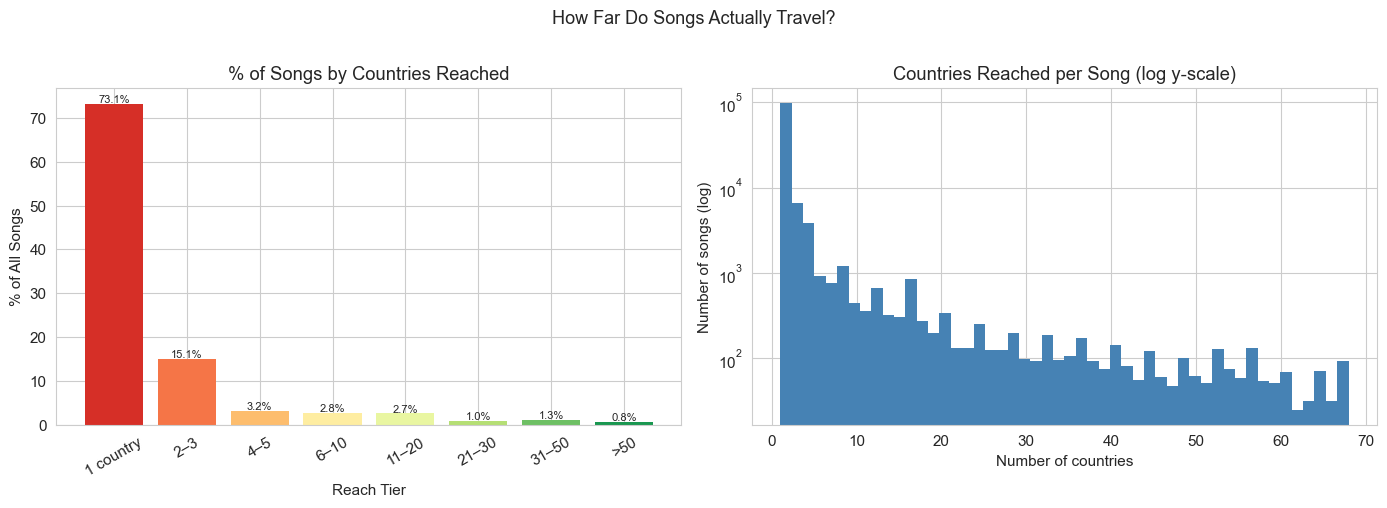

In [27]:
# ── 4.1 Compute geographic reach per song ──────────────────────────────────
spread = con.execute("""
    WITH first_entry AS (
        SELECT
            track_id,
            MAX(artist) AS artist,
            region,
            MIN(TRY_CAST(date AS DATE)) AS first_chart_date
        FROM spotify_clean
        GROUP BY track_id, region
    ),
    global_debut AS (
        SELECT track_id, MIN(first_chart_date) AS global_debut
        FROM first_entry
        GROUP BY track_id
    ),
    travel AS (
        SELECT
            fe.track_id,
            fe.artist,
            fe.region,
            fe.first_chart_date,
            gd.global_debut,
            DATEDIFF('day', gd.global_debut, fe.first_chart_date) AS days_to_arrive
        FROM first_entry fe
        JOIN global_debut gd USING (track_id)
    ),
    origin AS (
        SELECT track_id, ANY_VALUE(region) AS origin_country
        FROM travel
        WHERE days_to_arrive = 0
        GROUP BY track_id
    )
    SELECT
        t.track_id,
        t.artist,
        o.origin_country,
        COUNT(DISTINCT t.region) AS countries_reached,
        MEDIAN(t.days_to_arrive) AS median_days_to_arrive,
        MAX(t.days_to_arrive) AS max_spread_days,
        MIN(t.global_debut) AS global_debut
    FROM travel t
    LEFT JOIN origin o USING (track_id)
    GROUP BY t.track_id, t.artist, o.origin_country
""").df()

total_songs = len(spread)

# Reach tier breakdown
bins = [0, 1, 3, 5, 10, 20, 30, 50, float("inf")]
labels = ["1 country", "2–3", "4–5", "6–10", "11–20", "21–30", "31–50", ">50"]
spread["reach_tier"] = pd.cut(spread["countries_reached"], bins=bins, labels=labels, right=True)

tier_counts = spread.groupby("reach_tier", observed=True).size().reset_index(name="n_songs")
tier_counts["pct"] = (tier_counts["n_songs"] / total_songs * 100).round(2)

print(f"Total unique songs: {total_songs:,}")
print(f"Median reach: {spread['countries_reached'].median():.0f} countries")
print(f"Mean reach:   {spread['countries_reached'].mean():.1f} countries")
print(f"Songs in 1 country only: {(spread['countries_reached'] == 1).sum():,} ({(spread['countries_reached'] == 1).mean()*100:.1f}%)")
print()
display(tier_counts)

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(tier_counts)))
bars = axes[0].bar(tier_counts["reach_tier"], tier_counts["pct"], color=colors, edgecolor="none")
axes[0].set_title("% of Songs by Countries Reached")
axes[0].set_xlabel("Reach Tier")
axes[0].set_ylabel("% of All Songs")
axes[0].tick_params(axis="x", rotation=30)
for bar, pct in zip(bars, tier_counts["pct"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3, f"{pct:.1f}%", ha="center", fontsize=8)

axes[1].hist(spread["countries_reached"], bins=50, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_title("Countries Reached per Song (log y-scale)")
axes[1].set_xlabel("Number of countries")
axes[1].set_ylabel("Number of songs (log)")

plt.suptitle("How Far Do Songs Actually Travel?", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Geographic Reach:**

*To be completed after running.*

## 4.2 Target Threshold Selection

Test multiple thresholds for the binary target and evaluate class balance at each.

In [ ]:
# ── 4.2 Target threshold analysis ──────────────────────────────────────────
print("═" * 65)
print("  TARGET THRESHOLD ANALYSIS")
print("═" * 65)
print(f"  {'Threshold':<15} {'Positive':>10} {'Negative':>10} {'% Positive':>12}")
print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*12}")

thresholds = [2, 3, 5, 7, 10, 15, 20]
threshold_results = []

for t in thresholds:
    n_pos = (spread["countries_reached"] >= t).sum()
    n_neg = total_songs - n_pos
    pct = n_pos / total_songs * 100
    print(f"  >= {t:<11} {n_pos:>10,} {n_neg:>10,} {pct:>11.1f}%")
    threshold_results.append({"threshold": t, "n_pos": n_pos, "n_neg": n_neg, "pct_pos": pct})

threshold_df = pd.DataFrame(threshold_results)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(threshold_df["threshold"].astype(str), threshold_df["pct_pos"], color="steelblue", edgecolor="none")
ax.axhline(25, color="orange", ls="--", lw=1.5, label="25% target")
ax.axhline(35, color="red", ls="--", lw=1.5, label="35% target")
ax.set_xlabel("Threshold (countries reached >=)")
ax.set_ylabel("% Positive Class")
ax.set_title("Class Balance at Different Target Thresholds")
ax.legend()
for i, row in threshold_df.iterrows():
    ax.text(i, row["pct_pos"]+0.5, f"{row['pct_pos']:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n→ Select threshold that gives ~25–35% positive rate for balanced classification.")

**Findings — Target Threshold Selection:**

*To be completed after running. Select threshold and justify.*

## 4.3 Target Distribution by Year

Is international success becoming more or less common over time?

In [ ]:
# ── 4.3 Target by year ─────────────────────────────────────────────────────
# Choose threshold (adjust based on 4.2 findings)
TARGET_THRESHOLD = 5  # ADJUST AFTER RUNNING 4.2

spread["global_debut_dt"] = pd.to_datetime(spread["global_debut"])
spread["debut_year"] = spread["global_debut_dt"].dt.year
spread["is_international"] = (spread["countries_reached"] >= TARGET_THRESHOLD).astype(int)

yearly = spread.groupby("debut_year").agg(
    total_songs=("track_id", "count"),
    international_songs=("is_international", "sum")
).reset_index()
yearly["pct_international"] = (yearly["international_songs"] / yearly["total_songs"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly["debut_year"], yearly["total_songs"], color="steelblue", alpha=0.7, label="Total")
axes[0].bar(yearly["debut_year"], yearly["international_songs"], color="tomato", alpha=0.8, label=f"International (>={TARGET_THRESHOLD} countries)")
axes[0].set_title("Songs per Year: Total vs International")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Songs")
axes[0].legend()

axes[1].plot(yearly["debut_year"], yearly["pct_international"], marker="o", color="tomato", lw=2)
axes[1].set_title(f"% International Success by Year (threshold >= {TARGET_THRESHOLD})")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% International")
axes[1].set_ylim(0, yearly["pct_international"].max() * 1.3)

plt.tight_layout()
plt.show()
display(yearly)

print(f"\n→ This validates whether temporal train/test split (2017-2019 train, 2020 val, 2021 test) is feasible.")

**Findings — Target by Year:**

*To be completed after running.*

## 4.4 Target Distribution by Origin Country

Which origin countries produce the most internationally successful songs?

In [ ]:
# ── 4.4 Target by origin country ───────────────────────────────────────────
origin_success = spread.groupby("origin_country").agg(
    total_songs=("track_id", "count"),
    international=("is_international", "sum")
).reset_index()
origin_success["pct_international"] = (origin_success["international"] / origin_success["total_songs"] * 100).round(1)
origin_success = origin_success.sort_values("pct_international", ascending=False)

# Filter to countries with at least 50 songs (avoid noise from tiny samples)
origin_filtered = origin_success[origin_success["total_songs"] >= 50].head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: by % international
axes[0].barh(origin_filtered["origin_country"][::-1], origin_filtered["pct_international"][::-1], color="steelblue")
axes[0].set_title(f"% Songs Reaching >= {TARGET_THRESHOLD} Countries\n(min 50 songs, top 25)")
axes[0].set_xlabel("% International")

# Right: by absolute count
top_absolute = origin_success.sort_values("international", ascending=False).head(25)
axes[1].barh(top_absolute["origin_country"][::-1], top_absolute["international"][::-1], color="tomato")
axes[1].set_title(f"Absolute Count of International Songs\n(top 25)")
axes[1].set_xlabel("Number of International Songs")

plt.suptitle("International Success by Origin Country", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Target by Origin Country:**

*To be completed after running.*

---
# Part V — Descriptive Analysis of Feature Groups

## 5A — Country and Market Analysis

### 5.1 Stream Volume by Country

════════════════════════════════════════════════════════════
  AVERAGE STREAMS PER COUNTRY
════════════════════════════════════════════════════════════

  Total countries: 68


,region,n_entries,avg_streams,median_streams,max_streams,total_streams
0,United States,364081,390255.989208,294790.0,6146233,1.420848e+11
1,Brazil,364503,153263.777791,111785.0,2001683,5.586511e+10
2,Mexico,358331,127242.997592,97308.0,3680758,4.559511e+10
3,Germany,357342,111799.026311,80791.5,2629922,3.995049e+10
4,United Kingdom,359715,101198.344323,70095.0,2801638,3.640256e+10
...,...,...,...,...,...,...
63,Lithuania,152993,1938.003046,1520.0,86013,2.965009e+08
64,Estonia,107995,1790.969452,1486.0,29525,1.934157e+08
65,Latvia,150974,1728.479407,1448.0,23558,2.609554e+08
66,Bulgaria,94834,1707.914661,1401.0,30203,1.619684e+08


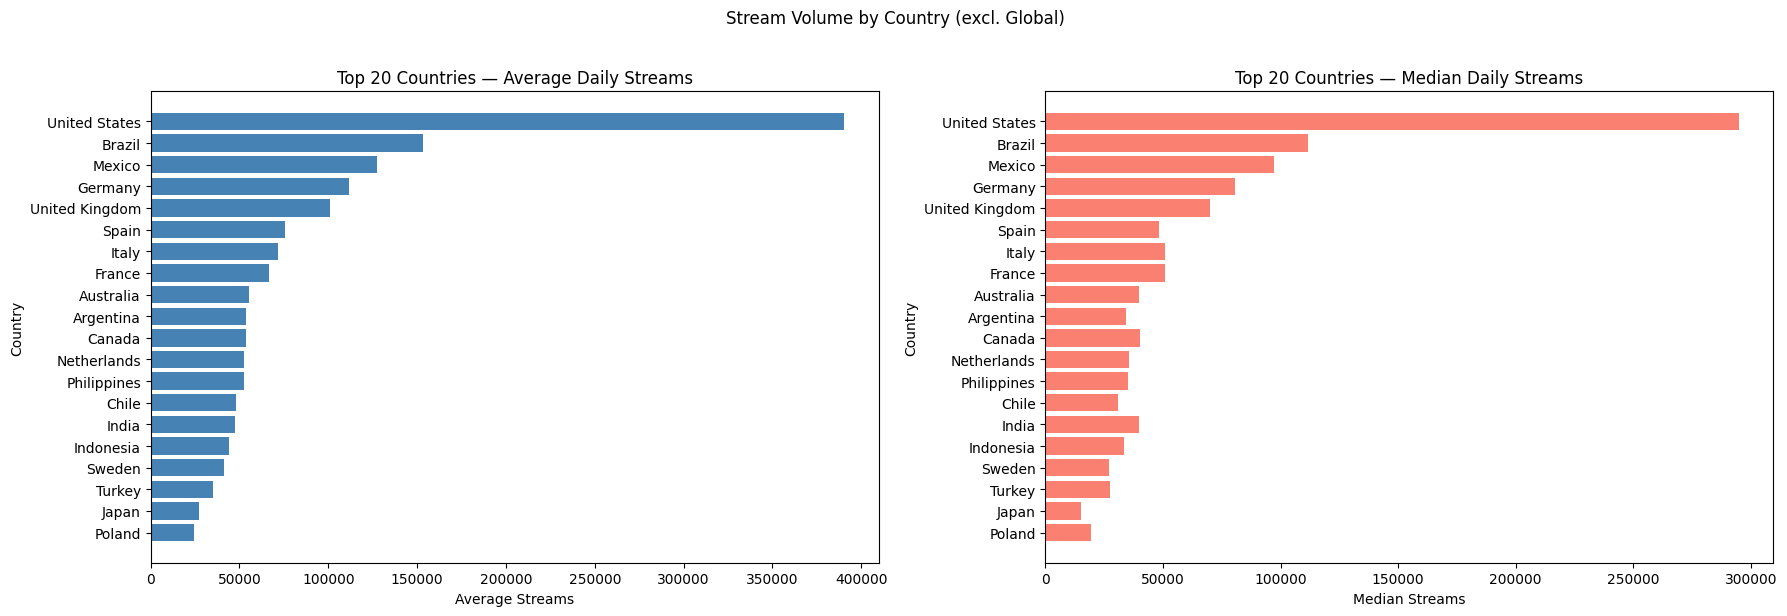


── Bottom 10 countries by average streams ───────────────────


,region,n_entries,avg_streams,median_streams,max_streams,total_streams
58,Egypt,123764,2551.200398,1936.0,74586,315746766.0
59,Slovakia,267583,2421.919012,1893.0,39470,648064355.0
60,United Arab Emirates,142051,2147.140823,1649.0,27573,305003501.0
61,Iceland,212061,2100.610112,1545.0,44069,445457481.0
62,Nicaragua,109995,2065.814528,1565.0,34289,227229269.0
63,Lithuania,152993,1938.003046,1520.0,86013,296500900.0
64,Estonia,107995,1790.969452,1486.0,29525,193415746.0
65,Latvia,150974,1728.479407,1448.0,23558,260955450.0
66,Bulgaria,94834,1707.914661,1401.0,30203,161968379.0
67,Luxembourg,8957,1658.866362,1386.0,16701,14858466.0


In [ ]:
# Average streams per country (excluding global) 
print("═" * 60)
print("  AVERAGE STREAMS PER COUNTRY")
print("═" * 60)

avg_streams_country = con.execute("""
    SELECT
        region,
        COUNT(*)                                          AS n_entries,
        AVG(TRY_CAST(streams AS DOUBLE))                 AS avg_streams,
        MEDIAN(TRY_CAST(streams AS DOUBLE))              AS median_streams,
        MAX(TRY_CAST(streams AS BIGINT))                 AS max_streams,
        SUM(TRY_CAST(streams AS BIGINT))                 AS total_streams
    FROM spotify_full
    WHERE streams IS NOT NULL
      AND track_id IS NOT NULL
      AND LOWER(region) != 'global'
    GROUP BY region
    ORDER BY avg_streams DESC
""").df()

print(f"\n  Total countries: {len(avg_streams_country):,}")
display(avg_streams_country)

# Bar chart: Top 20 countries by average streams 
top20 = avg_streams_country.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Average streams
axes[0].barh(top20["region"][::-1], top20["avg_streams"][::-1], color="steelblue")
axes[0].set_title("Top 20 Countries — Average Daily Streams")
axes[0].set_xlabel("Average Streams")
axes[0].set_ylabel("Country")

# Median streams (less affected by outliers)
axes[1].barh(top20["region"][::-1], top20["median_streams"][::-1], color="salmon")
axes[1].set_title("Top 20 Countries — Median Daily Streams")
axes[1].set_xlabel("Median Streams")
axes[1].set_ylabel("Country")

plt.suptitle("Stream Volume by Country (excl. Global)", y=1.02)
plt.tight_layout()
plt.show()

# Bottom 10 countries by average streams 
print("\n── Bottom 10 countries by average streams ───────────────────")
display(avg_streams_country.tail(10))

**Interpretation — Country Analysis:** The analysis confirms pronounced and structurally meaningful heterogeneity across markets. The United States records an average of approximately 390,000 daily streams per chart entry — roughly 235 times the average of Luxembourg, the lowest-volume market at approximately 1,658. Brazil, Mexico, Germany, and the United Kingdom form a second tier of large markets, each with averages substantially above the dataset median. The gap between mean and median stream counts is larger in bigger markets, consistent with those markets being more susceptible to viral outliers that inflate the mean without shifting the median.

Chart longevity varies considerably as well: some tracks remain charting for the full five-year span of the dataset in their home markets, while others appear for a single day. Days-on-chart is therefore not just a contextual detail — it is a potentially informative feature variable.

The continent-level box plots confirm the pattern: North and South American markets show consistently higher log(streams) medians than most European or Asian markets, though within-continent variance is substantial. This explains why continent dummy variables carry the largest coefficients in the linear baseline reported in Section 11.

**Section wrap-up:** Market heterogeneity is extreme and systematic. Stream volumes span multiple orders of magnitude, driven by structural differences in population size, platform penetration, and amplification dynamics. Any predictive model must account for geographic context. The next subsection asks whether a similar concentration effect operates at the artist level.

### 5.2 Continent-Level Stream Comparison

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/var/folders/19/93krsqv97cg550yjxmp0k48m0000gn/T/ipykernel_67584/3467280579.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=continents, vert=True)


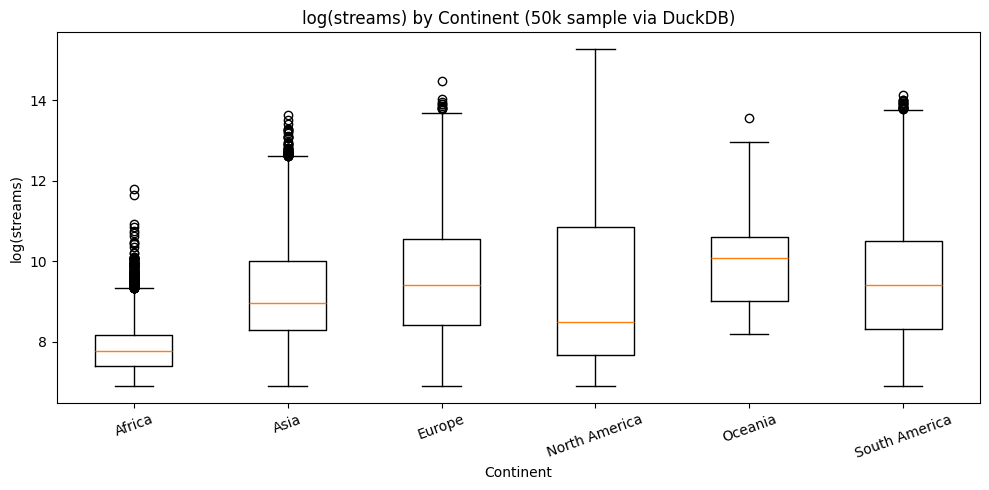

In [ ]:
continent_df = con.execute("""
    SELECT
        LN(TRY_CAST(streams AS DOUBLE)) AS log_streams,
        country_continent
    FROM spotify_full
    WHERE streams IS NOT NULL
      AND TRY_CAST(streams AS DOUBLE) > 0
      AND LOWER(region) != 'global'
      AND country_continent IS NOT NULL
    USING SAMPLE 500000
""").df()

continents = sorted(continent_df["country_continent"].dropna().unique())
groups = [
    continent_df.loc[continent_df["country_continent"] == c, "log_streams"].dropna().values
    for c in continents
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(groups, labels=continents, vert=True)
ax.set_title("log(streams) by Continent (50k sample via DuckDB)")
ax.set_xlabel("Continent")
ax.set_ylabel("log(streams)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### 5.3 Chart Longevity by Country

In [ ]:
# Shortest & Longest chart stay for a single song in any one country

# span_days = (last chart date − first chart date) + 1  for a given track × country
# "Shortest" = songs that appeared only 1 day in a country (span_days = 1)
# We show the top 10 on each end, plus the single extreme examples.

extremes = con.execute("""
    WITH song_spans AS (
        SELECT
            track_id,
            MAX(title)                                                           AS title,
            MAX(artist)                                                          AS artist,
            region,
            MIN(TRY_CAST(date AS DATE))                                          AS first_date,
            MAX(TRY_CAST(date AS DATE))                                          AS last_date,
            DATEDIFF('day',
                     MIN(TRY_CAST(date AS DATE)),
                     MAX(TRY_CAST(date AS DATE))) + 1                            AS span_days,
            COUNT(*)                                                             AS chart_entries,
            ROUND(AVG(TRY_CAST(rank AS DOUBLE)), 1)                              AS avg_rank
        FROM spotify_full
        WHERE region IS NOT NULL
          AND LOWER(region) != 'global'
          AND track_id IS NOT NULL
          AND title IS NOT NULL
          AND streams IS NOT NULL
        GROUP BY track_id, region
    )
    SELECT * FROM song_spans
    ORDER BY span_days DESC, chart_entries DESC
""").df()

# LONGEST stay
print("═" * 70)
print("  TOP 10 LONGEST CHART STAYS — single song in a single country")
print("═" * 70)
longest = extremes.head(10)[["title", "artist", "region", "first_date",
                               "last_date", "span_days", "chart_entries", "avg_rank"]]
display(longest.reset_index(drop=True))

# SHORTEST stay (span_days = 1, i.e. appeared on exactly one date)
print("\n" + "═" * 70)
print("  SONGS WITH THE SHORTEST CHART STAY (appeared on only 1 day in a country)")
print("═" * 70)

one_day = extremes[extremes["span_days"] == 1].copy()
print(f"\n  Total (track × country) combos with a 1-day stay : {len(one_day):,}")
print(f"  Distinct tracks                                   : {one_day['track_id'].nunique():,}")
print(f"  Distinct countries                                : {one_day['region'].nunique():,}")
print("\n  Sample of 10 one-day chart appearances:")
display(
    one_day[["title", "artist", "region", "first_date", "chart_entries", "avg_rank"]]
    .head(10)
    .reset_index(drop=True)
)

# Summary banner
longest_row  = extremes.iloc[0]
shortest_row = one_day.sort_values("chart_entries").iloc[0]

print("\n" + "═" * 70)
print("  SUMMARY")
print("═" * 70)
print(f"\n  Longest single-country chart run:")
print(f"     Song    : {longest_row['title']}")
print(f"     Artist  : {longest_row['artist']}")
print(f"     Country : {longest_row['region']}")
print(f"     Period  : {longest_row['first_date']}  →  {longest_row['last_date']}")
print(f"     Span    : {int(longest_row['span_days'])} days  ({int(longest_row['chart_entries'])} chart entries)")

print(f"\n  ⚡ Shortest single-country chart run (1 day):")
print(f"     Song    : {shortest_row['title']}")
print(f"     Artist  : {shortest_row['artist']}")
print(f"     Country : {shortest_row['region']}")
print(f"     Date    : {shortest_row['first_date']}")
print(f"     Entries : {int(shortest_row['chart_entries'])}  (avg rank {shortest_row['avg_rank']})")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

══════════════════════════════════════════════════════════════════════
  TOP 10 LONGEST CHART STAYS — single song in a single country
══════════════════════════════════════════════════════════════════════


,title,artist,region,first_date,last_date,span_days,chart_entries,avg_rank
0,Ohne mein Team,"Bonez MC, RAF Camora, Maxwell",Austria,2017-01-01,2021-12-31,1826,1806,96.4
1,goosebumps,Travis Scott,United States,2017-01-01,2021-12-31,1826,1778,97.1
2,No Role Modelz,J. Cole,United States,2017-01-01,2021-12-31,1826,1474,128.7
3,Don't Stop Believin',Journey,Austria,2017-01-01,2021-12-31,1826,878,173.0
4,Without Me,Eminem,Austria,2017-01-01,2021-12-31,1826,532,166.1
5,Ocho Cuarenta,Rodrigo,Argentina,2017-01-01,2021-12-31,1826,503,150.1
6,Una Cerveza,Rafaga,Argentina,2017-01-01,2021-12-31,1826,484,150.0
7,Deja De Llorar,El Polaco,Argentina,2017-01-01,2021-12-31,1826,294,147.9
8,Die For You,The Weeknd,United States,2017-01-01,2021-12-31,1826,282,155.7
9,Noche Loca,"Marama, Rombai",Argentina,2017-01-01,2021-12-31,1826,271,137.8



══════════════════════════════════════════════════════════════════════
  SONGS WITH THE SHORTEST CHART STAY (appeared on only 1 day in a country)
══════════════════════════════════════════════════════════════════════

  Total (track × country) combos with a 1-day stay : 76,989
  Distinct tracks                                   : 39,010
  Distinct countries                                : 68

  Sample of 10 one-day chart appearances:


,title,artist,region,first_date,chart_entries,avg_rank
0,Wicked Game,Chris Isaak,Sweden,2017-09-20,2,168.0
1,No Man is an Island,The Script,Ireland,2017-09-01,2,168.0
2,Deborah,Casper,Austria,2017-09-01,2,163.0
3,No Man is an Island,The Script,Netherlands,2017-09-01,2,171.0
4,BABE,HyunA,Taiwan,2017-09-26,2,184.0
5,No Man is an Island,The Script,Thailand,2017-09-01,2,100.0
6,Love Not Lovers,The Script,Singapore,2017-09-01,2,183.0
7,Love Not Lovers,The Script,Taiwan,2017-09-01,2,199.0
8,No Man is an Island,The Script,Malaysia,2017-09-01,2,155.0
9,ใครอีกคน,BOWKYLION,Thailand,2017-09-06,2,139.0



══════════════════════════════════════════════════════════════════════
  SUMMARY
══════════════════════════════════════════════════════════════════════

  Longest single-country chart run:
     Song    : Ohne mein Team
     Artist  : Bonez MC, RAF Camora, Maxwell
     Country : Austria
     Period  : 2017-01-01 00:00:00  →  2021-12-31 00:00:00
     Span    : 1826 days  (1806 chart entries)

  ⚡ Shortest single-country chart run (1 day):
     Song    : No New Friends
     Artist  : Sia, Diplo, Labrinth, LSD
     Country : Turkey
     Date    : 2019-03-15 00:00:00
     Entries : 1  (avg rank 96.0)


## 5B — Artist Analysis

### 5.4 Top Artists by Chart Appearances and Unique Songs

═════════════════════════════════════════════════════════════════
  1) BIGGEST ARTISTS IN THE DATA
═════════════════════════════════════════════════════════════════


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Total unique artists: 39,890

── Top 20 artists by chart appearances ──────────────────────


,artist,chart_appearances,unique_songs,countries_reached,active_days,avg_rank,total_streams
0,Ed Sheeran,355703,123,68,1823,95.7,1.051741e+10
1,Billie Eilish,222671,67,68,1404,93.7,7.527774e+09
2,Post Malone,189243,71,68,1823,88.7,9.338347e+09
3,Bad Bunny,184950,62,65,1823,84.0,5.150676e+09
4,Dua Lipa,169748,47,68,1823,82.9,5.605296e+09
5,Ariana Grande,169097,90,68,1823,85.9,7.015974e+09
6,Drake,150884,153,68,1822,83.4,8.866556e+09
7,Imagine Dragons,139994,89,68,1823,102.6,3.223163e+09
8,XXXTENTACION,135503,62,66,1797,108.9,5.499213e+09
9,The Weeknd,130631,59,68,1705,71.4,5.750073e+09



── Top 20 artists by unique songs ───────────────────────────


,artist,chart_appearances,unique_songs,countries_reached,active_days,avg_rank,total_streams
394,Jul,8003,257,5,1589,109.6,4.728192e+08
10,BTS,130056,230,68,1823,94.2,3.381890e+09
20,Taylor Swift,83198,214,68,1667,100.3,3.928982e+09
93,TWICE,27775,171,33,1810,105.7,5.045369e+08
6,Drake,150884,153,68,1822,83.4,8.866556e+09
8683,Die drei ???,179,138,1,35,166.0,9.696489e+06
13,Juice WRLD,106780,123,68,1351,100.9,6.363268e+09
0,Ed Sheeran,355703,123,68,1823,95.7,1.051741e+10
722,Djadja & Dinaz,4710,121,4,1468,113.4,2.466783e+08
733,Tory Lanez,4650,116,42,1070,126.3,2.896469e+08


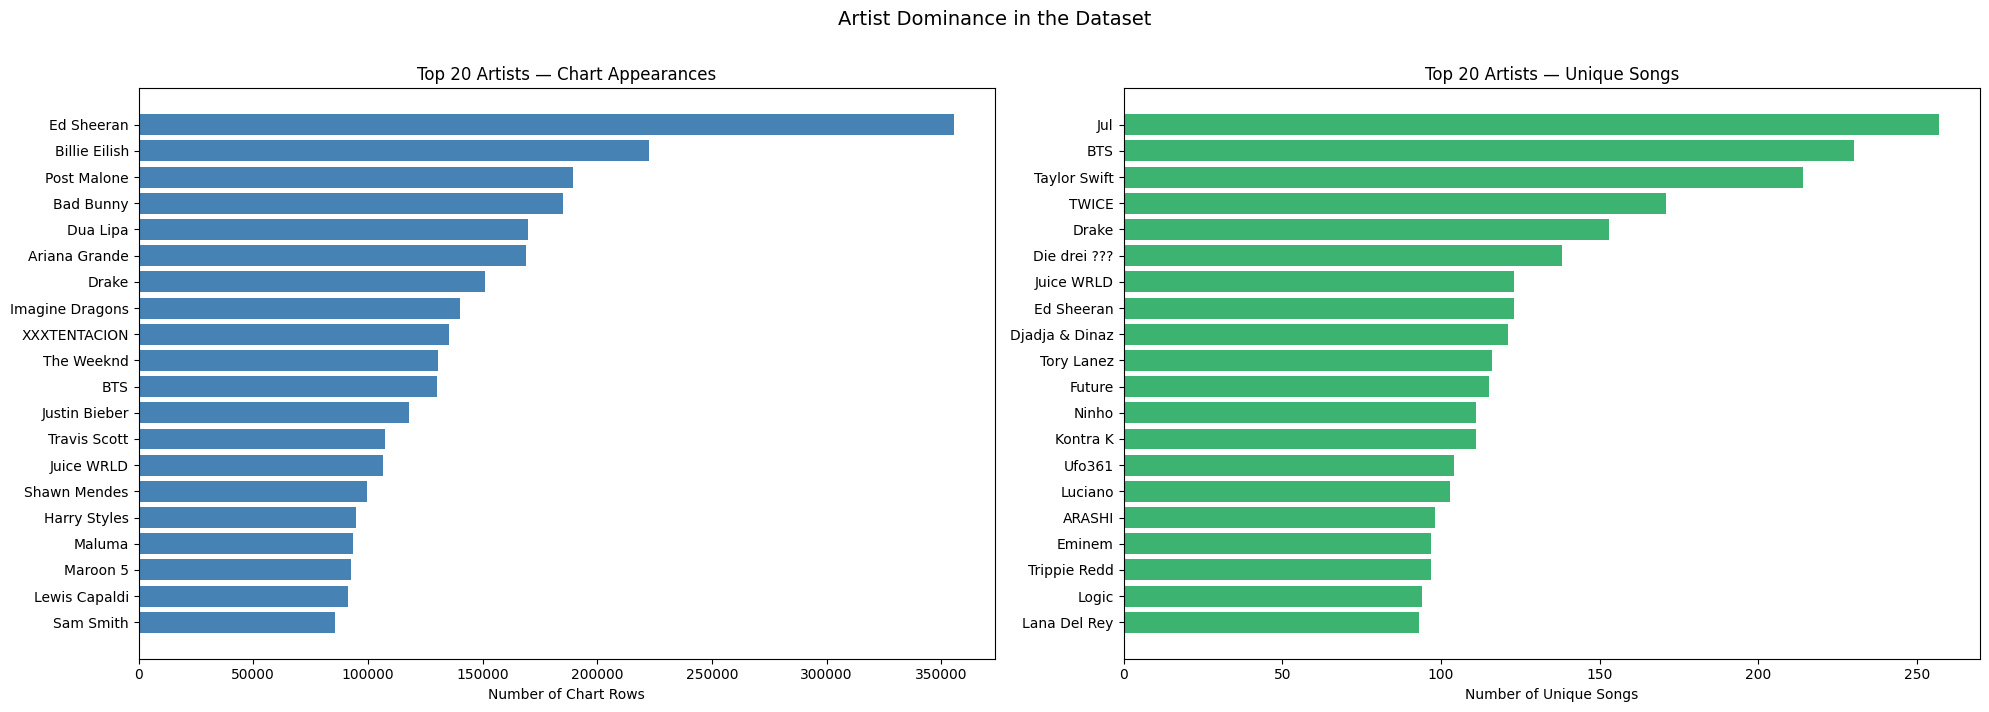

In [ ]:
# 1. TOP ARTISTS BY CHART APPEARANCES & UNIQUE SONGS
print("═" * 65)
print("  1) BIGGEST ARTISTS IN THE DATA")
print("═" * 65)

top_artists_appearances = con.execute("""
    SELECT
        artist,
        COUNT(*)                        AS chart_appearances,
        COUNT(DISTINCT track_id)        AS unique_songs,
        COUNT(DISTINCT region)          AS countries_reached,
        COUNT(DISTINCT date)            AS active_days,
        ROUND(AVG(TRY_CAST(rank AS DOUBLE)), 1)    AS avg_rank,
        SUM(TRY_CAST(streams AS BIGINT))            AS total_streams
    FROM spotify_full
    WHERE streams IS NOT NULL
      AND artist IS NOT NULL
      AND track_id IS NOT NULL
      AND LOWER(region) != 'global'
    GROUP BY artist
    ORDER BY chart_appearances DESC
""").df()

print(f"\n  Total unique artists: {len(top_artists_appearances):,}")
print("\n── Top 20 artists by chart appearances ──────────────────────")
display(top_artists_appearances.head(20))

print("\n── Top 20 artists by unique songs ───────────────────────────")
display(top_artists_appearances.sort_values("unique_songs", ascending=False).head(20))

# Plot: Top 20 by appearances vs unique songs
top20_app  = top_artists_appearances.head(20)
top20_songs = top_artists_appearances.sort_values("unique_songs", ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].barh(top20_app["artist"][::-1], top20_app["chart_appearances"][::-1], color="steelblue")
axes[0].set_title("Top 20 Artists — Chart Appearances")
axes[0].set_xlabel("Number of Chart Rows")

axes[1].barh(top20_songs["artist"][::-1], top20_songs["unique_songs"][::-1], color="mediumseagreen")
axes[1].set_title("Top 20 Artists — Unique Songs")
axes[1].set_xlabel("Number of Unique Songs")

plt.suptitle("Artist Dominance in the Dataset", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 5.5 Artist Concentration and Global Streaming Trend

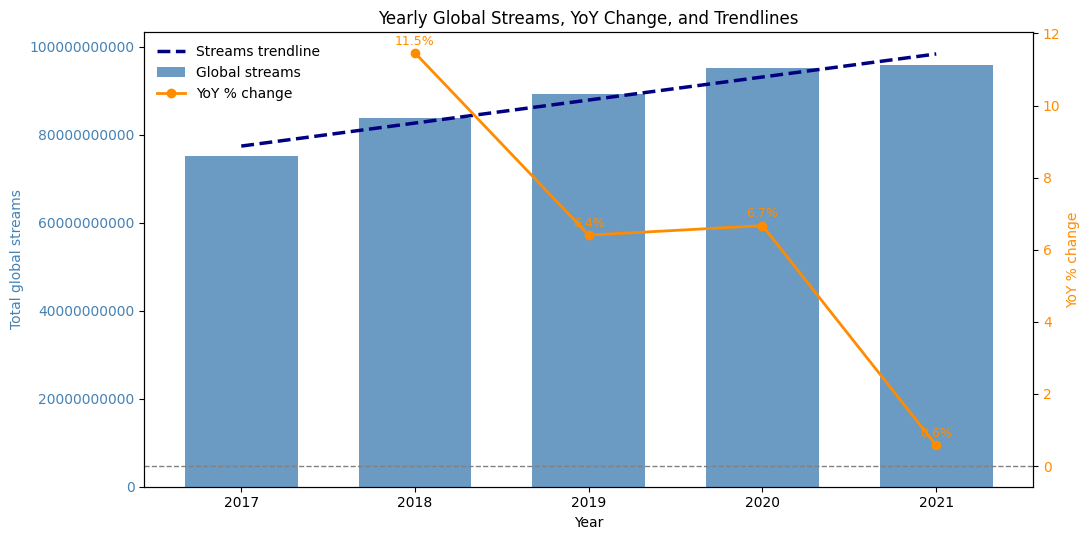

,year,global_streams,yoy_pct_change
0,2017,7.524887e+10,NaN
1,2018,8.387107e+10,11.458244
2,2019,8.924453e+10,6.406817
3,2020,9.519593e+10,6.668643
4,2021,9.574390e+10,0.575624


In [ ]:
# Yearly global streams + YoY % difference with trendlines
yearly_global_streams_df = con.execute("""
WITH base AS (
    SELECT
        COALESCE(
            TRY_CAST(year AS INTEGER),
            EXTRACT(YEAR FROM TRY_CAST(date AS DATE))::INTEGER
        ) AS year_val,
        TRY_CAST(streams AS DOUBLE) AS streams_num
    FROM spotify_full
    WHERE LOWER(region) = 'global'
)
SELECT
    year_val AS year,
    SUM(streams_num) AS global_streams
FROM base
WHERE year_val IS NOT NULL
  AND streams_num IS NOT NULL
GROUP BY year_val
ORDER BY year_val;
""").df()

yearly_global_streams_df["yoy_pct_change"] = yearly_global_streams_df["global_streams"].pct_change() * 100

x_year = yearly_global_streams_df["year"].astype(int).values
y_streams = yearly_global_streams_df["global_streams"].values
y_yoy = yearly_global_streams_df["yoy_pct_change"].values

fig, ax1 = plt.subplots(figsize=(11, 5.5))

# Bars: yearly global streams
ax1.bar(x_year, y_streams, color="steelblue", alpha=0.8, width=0.65, label="Global streams")

# Trendline for global streams (linear)
coef_streams = np.polyfit(x_year, y_streams, 1)
trend_streams = np.polyval(coef_streams, x_year)
ax1.plot(x_year, trend_streams, color="navy", linewidth=2.5, linestyle="--", label="Streams trendline")

ax1.set_xlabel("Year")
ax1.set_ylabel("Total global streams", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.ticklabel_format(axis='y', style='plain')
ax1.set_xticks(x_year)

# Line: YoY percentage change
ax2 = ax1.twinx()
ax2.plot(x_year, y_yoy, color="darkorange", marker="o", linewidth=2, label="YoY % change")


ax2.set_ylabel("YoY % change", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)

for x, y in zip(x_year, y_yoy):
    if pd.notnull(y):
        ax2.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 6), ha="center", color="darkorange", fontsize=9)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)

plt.title("Yearly Global Streams, YoY Change, and Trendlines")
fig.tight_layout()
plt.show()

display(yearly_global_streams_df)

**Interpretation — Artist Analysis:** Chart success is highly concentrated. Ed Sheeran leads with over 355,000 cumulative chart appearances across all 68 markets — a figure reflecting both the depth of his catalogue and his consistent presence in international charts throughout 2017–2021. The top 20 artists each vastly outperform the median artist in terms of cross-country reach, following a distribution consistent with the well-documented power-law structure of music streaming markets where a small elite captures a disproportionate share of attention.

Global streaming volumes show a consistent upward trend across the five-year period, reflecting the broader expansion of Spotify's user base. This temporal trend is relevant for modeling: a model trained on early years may encounter a different baseline when evaluated on later data, making temporal validation an important consideration.

**Modeling implication:** Artist concentration strongly motivates artist-level aggregation features — particularly a measure of how many countries an artist's prior work has charted in — as predictors. These features must be constructed carefully: they must be derived only from observations prior to the prediction date to prevent data leakage.

**Section wrap-up:** Both market-level and artist-level analyses reveal extreme concentration: a small number of countries and a small number of artists drive the majority of chart activity. The next subsection shifts from aggregate views to individual tracks, examining how widely individual songs actually spread across countries — the variable that defines the prediction target.

### 5.6 Artist Reach Distribution

How many countries does each artist reach? This directly informs the artist tier feature.

In [ ]:
# ── 5.6 Artist reach distribution ──────────────────────────────────────────
artist_reach = con.execute("""
    SELECT
        artist,
        COUNT(DISTINCT region) AS countries_reached,
        COUNT(DISTINCT track_id) AS unique_songs,
        COUNT(*) AS total_chart_entries
    FROM spotify_clean
    GROUP BY artist
""").df()

print(f"Total unique artists: {len(artist_reach):,}")
print(f"\nArtist reach distribution:")
print(f"  Median countries: {artist_reach['countries_reached'].median():.0f}")
print(f"  Mean countries:   {artist_reach['countries_reached'].mean():.1f}")

# Tier breakdown
artist_bins = [0, 1, 3, 5, 10, 15, 20, 30, float("inf")]
artist_labels = ["1", "2–3", "4–5", "6–10", "11–15", "16–20", "21–30", "31+"]
artist_reach["reach_tier"] = pd.cut(artist_reach["countries_reached"], bins=artist_bins, labels=artist_labels, right=True)

artist_tier_counts = artist_reach.groupby("reach_tier", observed=True).size().reset_index(name="n_artists")
artist_tier_counts["pct"] = (artist_tier_counts["n_artists"] / len(artist_reach) * 100).round(1)

print(f"\n{'Tier':<12} {'Artists':>10} {'%':>8}")
print(f"{'-'*12} {'-'*10} {'-'*8}")
for _, row in artist_tier_counts.iterrows():
    print(f"{str(row['reach_tier']):<12} {int(row['n_artists']):>10,} {row['pct']:>7.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(artist_reach["countries_reached"], bins=50, color="steelblue", edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_title("Countries Reached per Artist (log y-scale)")
axes[0].set_xlabel("Number of countries")
axes[0].set_ylabel("Number of artists (log)")

axes[1].hist(artist_reach[artist_reach["countries_reached"] > 1]["countries_reached"], bins=50, color="tomato", edgecolor="none")
axes[1].set_title("Countries Reached per Artist (excluding single-country artists)")
axes[1].set_xlabel("Number of countries")
axes[1].set_ylabel("Number of artists")

plt.suptitle("Artist Reach Distribution", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Artist Reach Distribution:**

*To be completed after running.*

## 5C — Audio Feature Analysis

### 5.7 Audio Feature Distributions

In [ ]:
# Pull a 50 000-row random sample for plotting (avoids loading 26M rows into memory)
SAMPLE_SIZE = 1_000_000

sample_df = con.execute(f"""
    SELECT
        TRY_CAST(streams AS DOUBLE) AS streams,
        TRY_CAST(af_danceability AS DOUBLE) AS danceability,
        TRY_CAST(af_energy AS DOUBLE) AS energy,
        TRY_CAST(af_valence AS DOUBLE) AS valence,
        TRY_CAST(af_tempo AS DOUBLE) AS tempo,
        TRY_CAST(af_loudness AS DOUBLE) AS loudness,
        TRY_CAST(af_acousticness AS DOUBLE) AS acousticness,
        TRY_CAST(af_speechiness AS DOUBLE) AS speechiness,
        TRY_CAST(af_instrumentalness AS DOUBLE) AS instrumentalness,
        TRY_CAST(af_liveness AS DOUBLE) AS liveness,
        TRY_CAST(rank AS DOUBLE) AS rank,
        TRY_CAST(popularity AS DOUBLE) AS popularity,
        chart,
        explicit,
        country_continent,
        year
    FROM spotify_full
    USING SAMPLE {SAMPLE_SIZE} ROWS
""").df()

# Add log_streams
sample_df["log_streams"] = np.log1p(sample_df["streams"].clip(lower=0))

print(f"Sample shape: {sample_df.shape}")
print("\nSample describe (numeric features):")
display(sample_df.describe())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sample shape: (1000000, 17)

Sample describe (numeric features):


,streams,danceability,energy,valence,tempo,loudness,acousticness,speechiness,instrumentalness,liveness,rank,popularity,year,log_streams
count,7.762730e+05,988416.000000,988416.000000,988416.000000,988416.000000,988416.000000,988416.000000,988416.000000,988416.000000,988416.000000,1000000.000000,988416.000000,1000000.000000,776273.000000
mean,5.519784e+04,0.685793,0.643686,0.522730,121.208553,-6.240121,0.258042,0.109804,0.013454,0.169267,80.847273,46.679095,2019.133020,9.401532
std,2.074562e+05,0.137322,0.166718,0.223174,29.426060,2.512806,0.246473,0.100065,0.085019,0.129016,59.153525,30.836694,1.389944,1.558110
min,1.001000e+03,0.000000,0.000020,0.000000,0.000000,-43.988000,0.000000,0.000000,0.000000,0.013400,1.000000,0.000000,2017.000000,6.909753
25%,3.538000e+03,0.601000,0.536000,0.349000,97.028000,-7.463000,0.056300,0.042800,0.000000,0.093400,29.000000,7.000000,2018.000000,8.171599
50%,9.590000e+03,0.704000,0.662000,0.522000,118.852000,-5.853500,0.177000,0.067400,0.000000,0.120000,67.000000,57.000000,2019.000000,9.168580
75%,3.541100e+04,0.785000,0.770000,0.697000,140.016000,-4.524000,0.396000,0.136000,0.000026,0.196000,131.000000,73.000000,2020.000000,10.474806
max,1.097739e+07,0.987000,1.000000,0.995000,233.872000,2.240000,0.996000,0.966000,0.987000,0.994000,200.000000,96.000000,2021.000000,16.211348


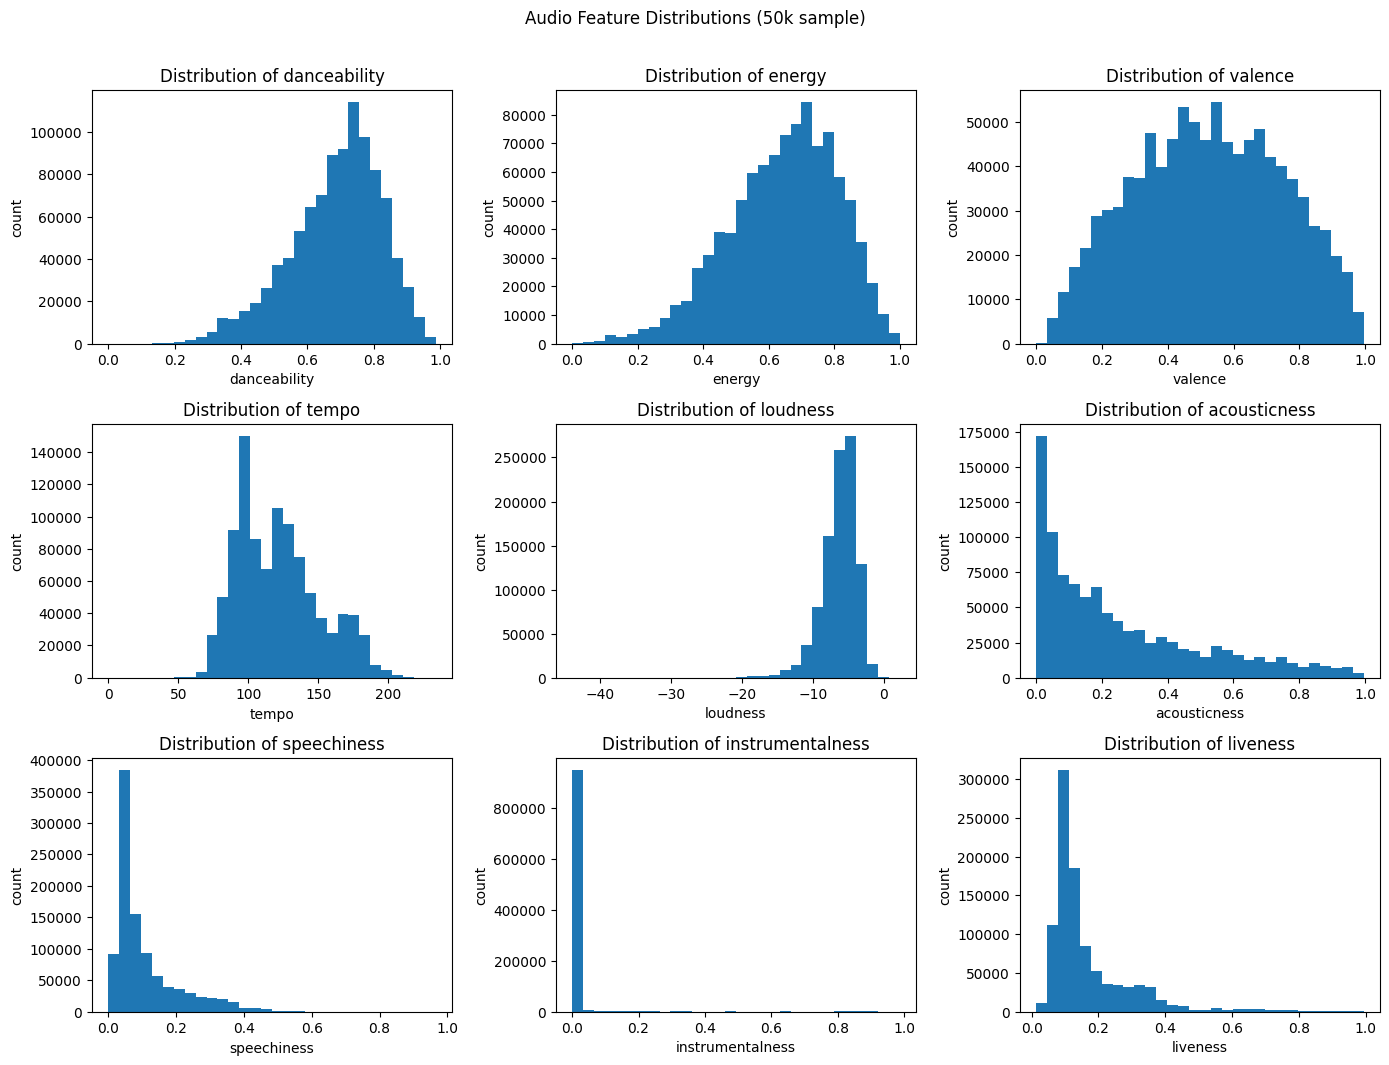

In [ ]:
# Histograms of all numeric audio features 
audio_features = ["danceability", "energy", "valence", "tempo",
                   "loudness", "acousticness", "speechiness",
                   "instrumentalness", "liveness"]

n_cols = 3
n_rows = (len(audio_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.ravel()

for i, feat in enumerate(audio_features):
    data = sample_df[feat].dropna()
    axes[i].hist(data, bins=30, edgecolor="none")
    axes[i].set_title(f"Distribution of {feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("count")

# Hide unused axes
for j in range(len(audio_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Audio Feature Distributions (50k sample)", y=1.01)
plt.tight_layout()
plt.show()


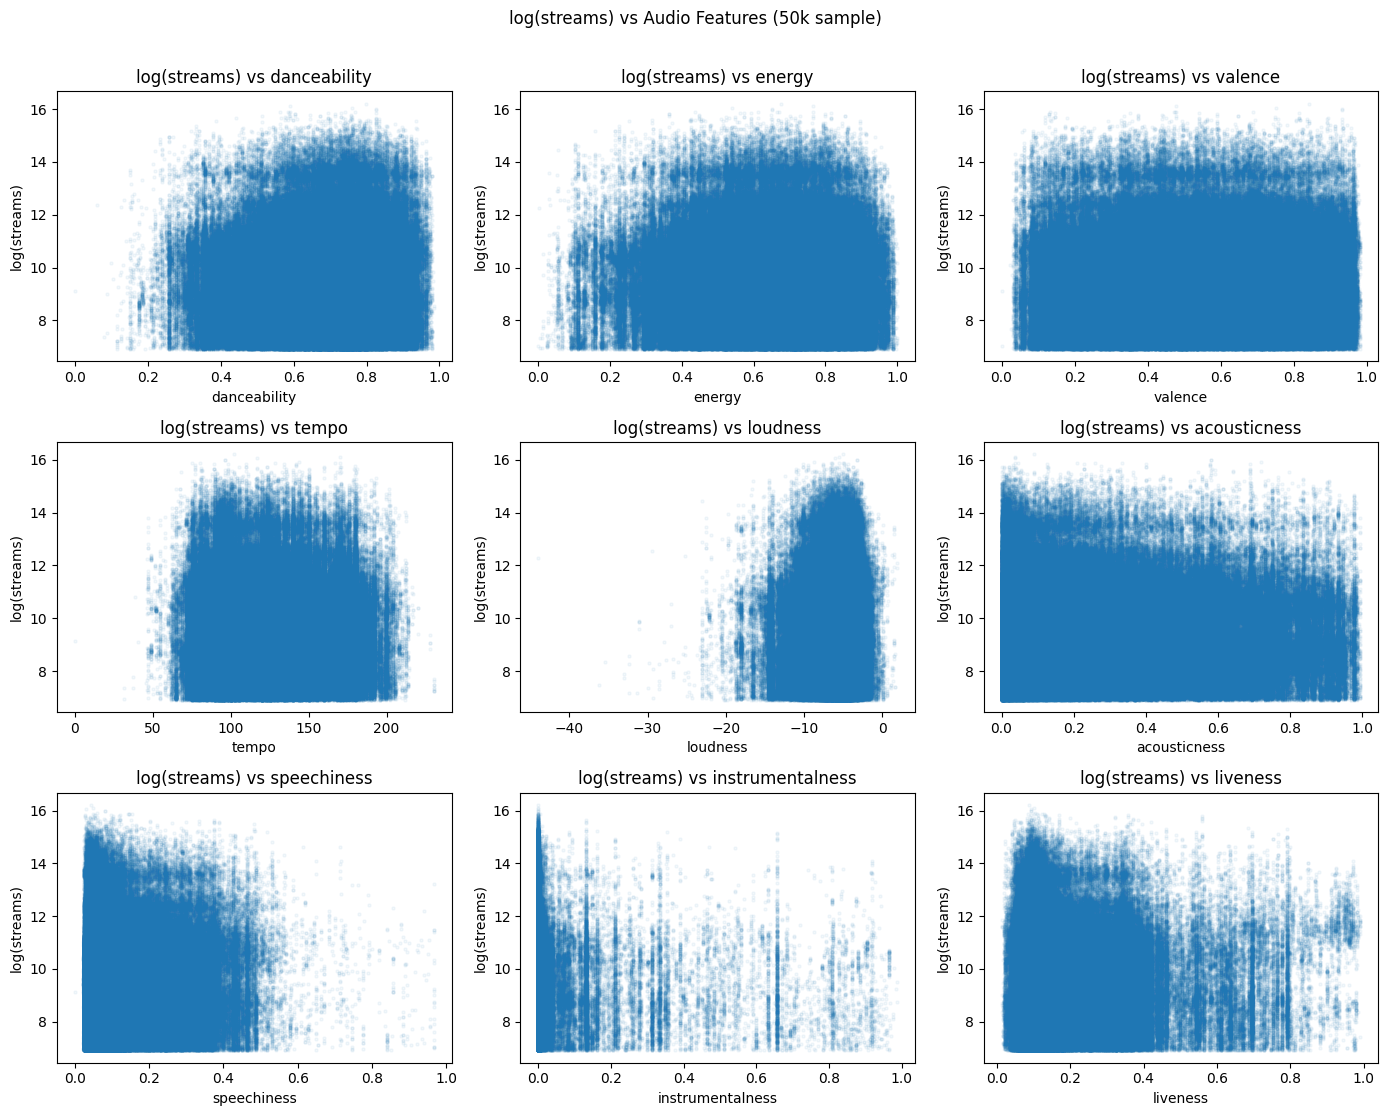

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()

for i, feat in enumerate(audio_features):
    x = sample_df[feat].dropna()
    y = sample_df.loc[x.index, "log_streams"].dropna()
    common = x.index.intersection(y.index)
    axes[i].scatter(x[common], y[common], alpha=0.05, s=5)
    axes[i].set_title(f"log(streams) vs {feat}")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("log(streams)")

plt.suptitle("log(streams) vs Audio Features (50k sample)", y=1.01)
plt.tight_layout()
plt.show()

**Interpretation — Audio Feature Distributions:** The nine histograms reveal distinct and practically relevant distributional shapes. Danceability and energy exhibit roughly bell-shaped distributions centred near 0.6, consistent with the mainstream pop, urban, and dance genres that dominate global charts. Valence and acousticness show broader distributions, indicating genuine stylistic diversity among charting songs.

Speechiness and instrumentalness are both strongly right-skewed, with the vast majority of tracks concentrated near zero. This reflects the dominance of melodic vocal music in streaming charts — purely spoken-word or purely instrumental tracks are rare. The implication is that these features may be most useful as binary or near-binary indicators ("is this track highly instrumental?") rather than as continuous variables in linear models.

Loudness is left-skewed with most values between −10 and −3 dB, consistent with modern chart music production norms and Spotify's loudness normalisation. Key (chromatic pitch class, integer 0–11) and mode (binary: major/minor) are effectively categorical and should be dummy-encoded in preprocessing rather than used as raw integers. Liveness is moderately right-skewed, with a small tail of high-scoring tracks likely corresponding to live recordings.

**Section wrap-up:** Several audio features require preprocessing attention: speechiness and instrumentalness are candidates for log-transformation or binarisation; key and mode should be encoded as categories; energy and loudness will require multicollinearity assessment. These observations motivate the preprocessing choices formalised in the correlation analysis and the pipeline construction that follows.

### 5.8 Audio Features by Reach Tier

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

══════════════════════════════════════════════════════════════════════
  AVERAGE AUDIO FEATURES BY REACH TIER
══════════════════════════════════════════════════════════════════════


,danceability,energy,valence,acousticness,speechiness,instrumentalness,liveness,loudness,tempo
reach_tier,,,,,,,,,
1 country,0.6618,0.6311,0.5101,0.2900,0.1273,0.0279,0.1773,-7.3185,121.5131
2–3 countries,0.6893,0.6497,0.5056,0.2467,0.1526,0.0211,0.1725,-6.7631,121.9408
4–5 countries,0.6824,0.6451,0.5026,0.2418,0.1352,0.0169,0.1724,-6.5452,122.1950
6–10 countries,0.6617,0.6601,0.5103,0.2270,0.1045,0.0213,0.1802,-6.1563,121.9439
11–20 countries,0.6818,0.6633,0.5406,0.2329,0.1129,0.0169,0.1761,-5.9922,122.5757
21–30 countries,0.6578,0.6422,0.4711,0.2225,0.1218,0.0104,0.1854,-6.4562,120.2102
31–50 countries,0.6555,0.6192,0.4604,0.2351,0.1142,0.0152,0.1840,-6.6012,119.8394
>50 countries,0.6701,0.6264,0.4765,0.2279,0.1008,0.0107,0.1665,-6.3308,121.1352


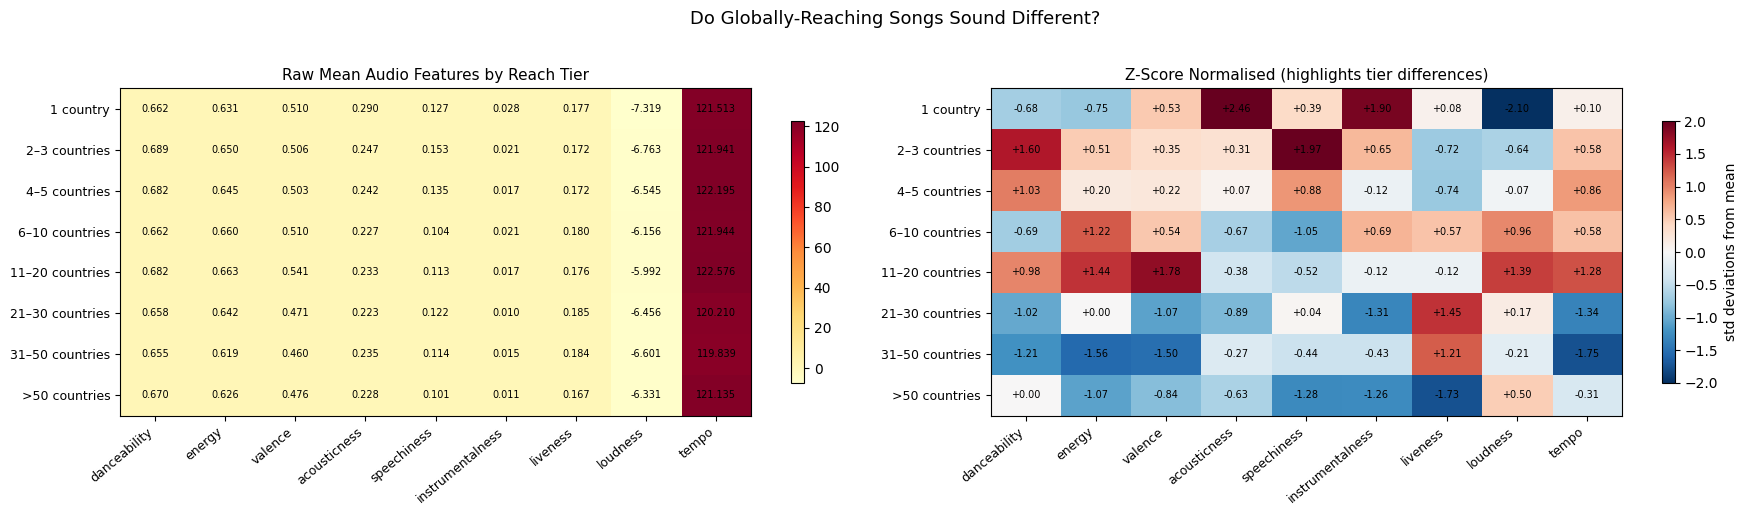

In [ ]:
# Average Audio Features per Reach Tier 
# Pull one row of audio features per track_id (first occurrence, deduplicated)
audio_raw = con.execute("""
    SELECT
        track_id,
        AVG(TRY_CAST(af_danceability     AS DOUBLE)) AS danceability,
        AVG(TRY_CAST(af_energy           AS DOUBLE)) AS energy,
        AVG(TRY_CAST(af_valence          AS DOUBLE)) AS valence,
        AVG(TRY_CAST(af_acousticness     AS DOUBLE)) AS acousticness,
        AVG(TRY_CAST(af_speechiness      AS DOUBLE)) AS speechiness,
        AVG(TRY_CAST(af_instrumentalness AS DOUBLE)) AS instrumentalness,
        AVG(TRY_CAST(af_liveness         AS DOUBLE)) AS liveness,
        AVG(TRY_CAST(af_loudness         AS DOUBLE)) AS loudness,
        AVG(TRY_CAST(af_tempo            AS DOUBLE)) AS tempo
    FROM spotify_full
    WHERE track_id IS NOT NULL
    GROUP BY track_id
""").df()

# Join with spread to get reach_tier
spread_audio = spread[["track_id", "reach_tier"]].merge(audio_raw, on="track_id", how="left")

audio_features_cols = [
    "danceability", "energy", "valence", "acousticness",
    "speechiness", "instrumentalness", "liveness", "loudness", "tempo"
]

tier_audio = (
    spread_audio.groupby("reach_tier", observed=True)[audio_features_cols]
    .mean()
    .round(4)
)

print("═" * 70)
print("  AVERAGE AUDIO FEATURES BY REACH TIER")
print("═" * 70)
display(tier_audio)

# Heatmap (z-score normalised so all features are comparable) 
from scipy.stats import zscore

tier_audio_z = tier_audio.apply(zscore, axis=0)   # normalise each feature column

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: raw average values heatmap
im1 = axes[0].imshow(tier_audio.values, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks(range(len(audio_features_cols)))
axes[0].set_xticklabels(audio_features_cols, rotation=40, ha="right", fontsize=9)
axes[0].set_yticks(range(len(tier_audio)))
axes[0].set_yticklabels(tier_audio.index, fontsize=9)
axes[0].set_title("Raw Mean Audio Features by Reach Tier", fontsize=11)
for i in range(len(tier_audio)):
    for j in range(len(audio_features_cols)):
        axes[0].text(j, i, f"{tier_audio.values[i, j]:.3f}",
                     ha="center", va="center", fontsize=7, color="black")
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Right: z-score normalised — highlights which features distinguish tiers
im2 = axes[1].imshow(tier_audio_z.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
axes[1].set_xticks(range(len(audio_features_cols)))
axes[1].set_xticklabels(audio_features_cols, rotation=40, ha="right", fontsize=9)
axes[1].set_yticks(range(len(tier_audio_z)))
axes[1].set_yticklabels(tier_audio_z.index, fontsize=9)
axes[1].set_title("Z-Score Normalised (highlights tier differences)", fontsize=11)
for i in range(len(tier_audio_z)):
    for j in range(len(audio_features_cols)):
        axes[1].text(j, i, f"{tier_audio_z.values[i, j]:+.2f}",
                     ha="center", va="center", fontsize=7, color="black")
plt.colorbar(im2, ax=axes[1], shrink=0.8, label="std deviations from mean")

plt.suptitle("Do Globally-Reaching Songs Sound Different?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5D — Diffusion Timeline Analysis

### 5.9 Diffusion Timeline — Days to Arrive

Computing first chart date per track per country … (may take a moment)
  Rows (track × country × chart): 359,369
  Songs tracked : 117,876
  Median days to arrive in a new country: 12 days
  Mean   days to arrive in a new country: 102.4 days

════════════════════════════════════════════════════════════
  SPREAD WIDTH — songs by countries reached
════════════════════════════════════════════════════════════
  Median countries reached per song : 1
  Mean   countries reached per song : 3.0
  Songs reaching ≥ 30 countries     : 2,475
  Songs reaching ≥ 50 countries     : 943


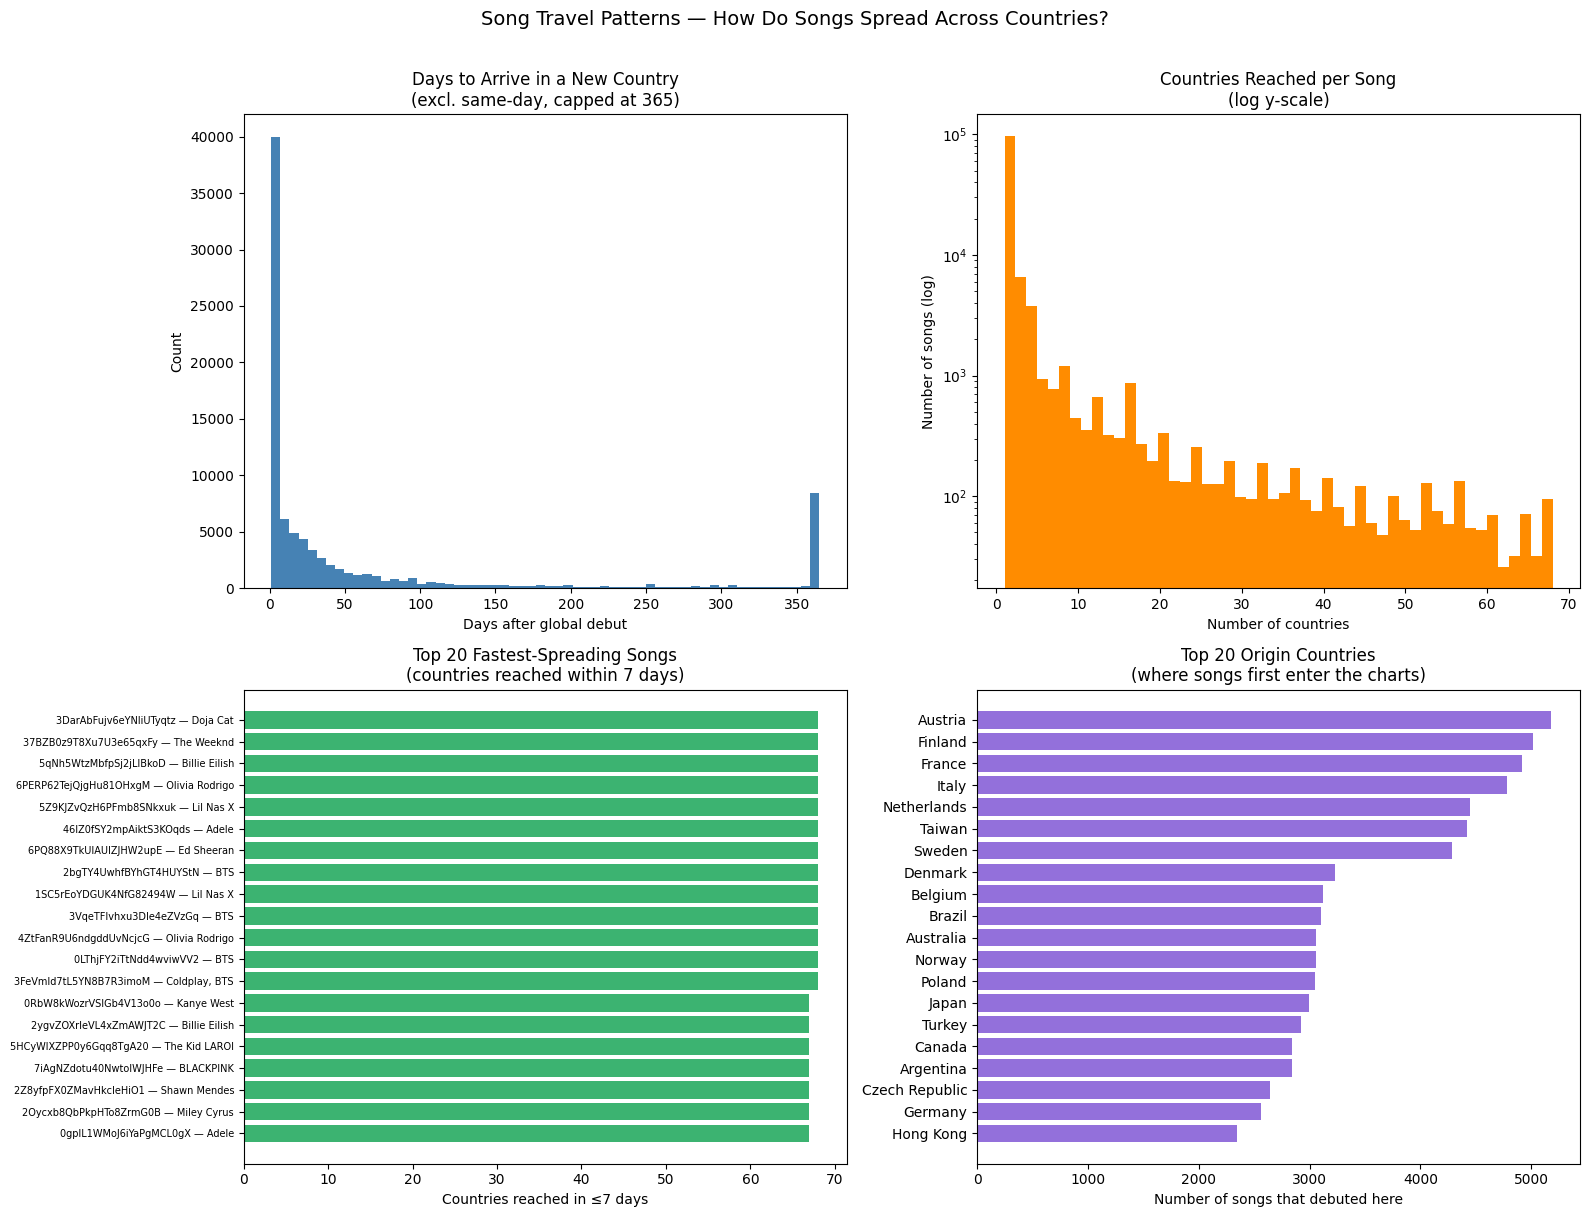


── Top 20 widest-spreading songs (most countries reached) ───


,artist,origin_country,countries_reached,days_to_50pct,max_spread_days
0,Lady Gaga,Argentina,68,0.0,250
1,BLACKPINK,Argentina,68,0.0,122
2,Doja Cat,United States,68,24.5,421
3,Ariana Grande,Argentina,68,0.0,94
4,BTS,Argentina,68,0.0,0
5,Dua Lipa,Argentina,68,0.0,311
6,Billie Eilish,Australia,68,0.0,81
7,Lil Nas X,Australia,68,0.0,42
8,Ariana Grande,Argentina,68,0.0,732
9,Doja Cat,Argentina,68,0.0,0



── Spread speed by chart type ───────────────────────────────


,chart,median_days,mean_days,n_arrivals
0,top200,12.0,102.4,90206


In [ ]:
# For each (track_id, region) pair, find the first date it appeared on any chart.
# Then compute how many days after the track's global debut it reached each country.

# Step 1: First chart date per (track_id, region) 
print("Computing first chart date per track per country … (may take a moment)")

first_entry = con.execute("""
    SELECT
        track_id,
        artist,
        region,
        chart,
        MIN(CAST(date AS DATE)) AS first_chart_date
    FROM spotify_full
    WHERE track_id  IS NOT NULL
      AND streams   IS NOT NULL
      AND region    IS NOT NULL
      AND LOWER(region) != 'global'
    GROUP BY track_id, artist, region, chart
""").df()

first_entry["first_chart_date"] = pd.to_datetime(first_entry["first_chart_date"])
print(f"  Rows (track × country × chart): {len(first_entry):,}")

# Step 2: Global debut = earliest first_chart_date across all countries 
global_debut = (
    first_entry
    .groupby("track_id")["first_chart_date"]
    .min()
    .reset_index()
    .rename(columns={"first_chart_date": "global_debut"})
)

travel = first_entry.merge(global_debut, on="track_id")
travel["days_to_arrive"] = (travel["first_chart_date"] - travel["global_debut"]).dt.days

# Origin country = the country where days_to_arrive == 0
origin = (
    travel[travel["days_to_arrive"] == 0]
    .groupby("track_id")["region"]
    .agg(lambda x: x.mode().iloc[0])   # most common origin when tied
    .reset_index()
    .rename(columns={"region": "origin_country"})
)
travel = travel.merge(origin, on="track_id", how="left")

print(f"  Songs tracked : {travel['track_id'].nunique():,}")
print(f"  Median days to arrive in a new country: {travel[travel['days_to_arrive'] > 0]['days_to_arrive'].median():.0f} days")
print(f"  Mean   days to arrive in a new country: {travel[travel['days_to_arrive'] > 0]['days_to_arrive'].mean():.1f} days")

# Step 3: Spread width per song 
spread = (
    travel.groupby(["track_id", "artist", "origin_country"])
    .agg(
        countries_reached = ("region",          "nunique"),
        days_to_50pct     = ("days_to_arrive",  lambda x: x.quantile(0.5)),
        max_spread_days   = ("days_to_arrive",  "max"),
    )
    .reset_index()
)

print("\n" + "═" * 60)
print("  SPREAD WIDTH — songs by countries reached")
print("═" * 60)
print(f"  Median countries reached per song : {spread['countries_reached'].median():.0f}")
print(f"  Mean   countries reached per song : {spread['countries_reached'].mean():.1f}")
print(f"  Songs reaching ≥ 30 countries     : {(spread['countries_reached'] >= 30).sum():,}")
print(f"  Songs reaching ≥ 50 countries     : {(spread['countries_reached'] >= 50).sum():,}")

# Step 4: Visualisations 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Distribution of days_to_arrive (excluding same-day)
later = travel[travel["days_to_arrive"] > 0]["days_to_arrive"].clip(upper=365)
axes[0, 0].hist(later, bins=60, color="steelblue", edgecolor="none")
axes[0, 0].set_title("Days to Arrive in a New Country\n(excl. same-day, capped at 365)")
axes[0, 0].set_xlabel("Days after global debut")
axes[0, 0].set_ylabel("Count")

# (b) Distribution of spread width (# countries per song)
axes[0, 1].hist(spread["countries_reached"], bins=50, color="darkorange", edgecolor="none")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Countries Reached per Song\n(log y-scale)")
axes[0, 1].set_xlabel("Number of countries")
axes[0, 1].set_ylabel("Number of songs (log)")

# (c) Top 20 fastest-spreading songs (most countries within 7 days)
fast = (
    travel[travel["days_to_arrive"] <= 7]
    .groupby(["track_id", "artist"])["region"]
    .nunique()
    .reset_index()
    .rename(columns={"region": "countries_in_7d"})
    .sort_values("countries_in_7d", ascending=False)
    .head(20)
)
axes[1, 0].barh(
    (fast["track_id"].str[:25] + " — " + fast["artist"].str[:15])[::-1],
    fast["countries_in_7d"][::-1],
    color="mediumseagreen"
)
axes[1, 0].set_title("Top 20 Fastest-Spreading Songs\n(countries reached within 7 days)")
axes[1, 0].set_xlabel("Countries reached in ≤7 days")
axes[1, 0].tick_params(axis="y", labelsize=7)

# (d) Top 20 most common origin countries (where songs chart first)
top_origins = (
    origin.merge(spread[["track_id"]], on="track_id")
    .groupby("origin_country")
    .size()
    .reset_index(name="n_songs_originated")
    .sort_values("n_songs_originated", ascending=False)
    .head(20)
)
axes[1, 1].barh(
    top_origins["origin_country"][::-1],
    top_origins["n_songs_originated"][::-1],
    color="mediumpurple"
)
axes[1, 1].set_title("Top 20 Origin Countries\n(where songs first enter the charts)")
axes[1, 1].set_xlabel("Number of songs that debuted here")

plt.suptitle("Song Travel Patterns — How Do Songs Spread Across Countries?", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Step 5: Top 20 widest-spreading songs 
print("\n── Top 20 widest-spreading songs (most countries reached) ───")
display(
    spread.sort_values("countries_reached", ascending=False)
    .head(20)[["artist", "origin_country",
               "countries_reached", "days_to_50pct", "max_spread_days"]]
    .reset_index(drop=True)
)

# Step 6: Spread speed by chart type 
print("\n── Spread speed by chart type ───────────────────────────────")
chart_speed = (
    travel[travel["days_to_arrive"] > 0]
    .groupby("chart")["days_to_arrive"]
    .agg(["median", "mean", "count"])
    .round(1)
    .rename(columns={"median": "median_days", "mean": "mean_days", "count": "n_arrivals"})
    .sort_values("median_days")
    .reset_index()
)
display(chart_speed)


### 5.10 365-Day Spike Diagnosis

════════════════════════════════════════════════════════════
  DIAGNOSING THE 365-DAY SPIKE
════════════════════════════════════════════════════════════

  Total arrivals with days_to_arrive > 0  : 90,206
  Arrivals with exactly 365 days          : 185
  Arrivals with days_to_arrive > 365      : 7,700
  Arrivals within ±5 days of 365          : 1,050

  ➜ The spike = 7,885 observations piled into one bin by .clip(upper=365)

── Arrivals by time bucket ──────────────────────────────────
  ≤ 7d           39,994  ( 44.3%)  ████████████████████████████████████████████
  8–30d          18,164  ( 20.1%)  ████████████████████
  31–90d         13,859  ( 15.4%)  ███████████████
  91–180d         5,203  (  5.8%)  █████
  181–365d        5,286  (  5.9%)  █████
  366–730d        4,167  (  4.6%)  ████
  > 730d          3,533  (  3.9%)  ███


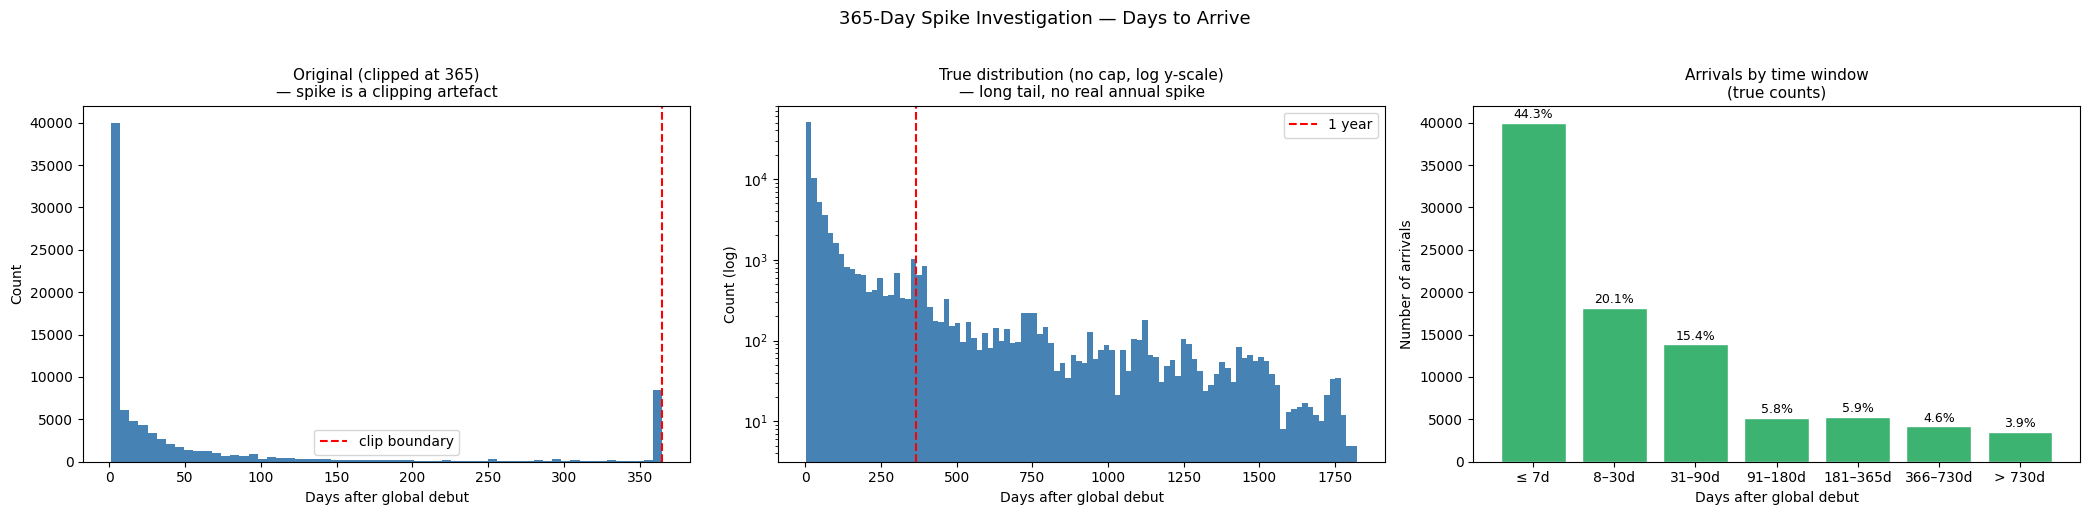

In [ ]:
# Investigate the 365-day spike 
later = travel[travel["days_to_arrive"] > 0]["days_to_arrive"]

# 1. Prove the spike is a clipping artefact
total_over_365  = (later > 365).sum()
total_at_365    = (later == 365).sum()
total_near_365  = ((later >= 360) & (later <= 370)).sum()

print("═" * 60)
print("  DIAGNOSING THE 365-DAY SPIKE")
print("═" * 60)
print(f"\n  Total arrivals with days_to_arrive > 0  : {len(later):,}")
print(f"  Arrivals with exactly 365 days          : {total_at_365:,}")
print(f"  Arrivals with days_to_arrive > 365      : {total_over_365:,}")
print(f"  Arrivals within ±5 days of 365          : {total_near_365:,}")
print(f"\n  ➜ The spike = {total_at_365 + total_over_365:,} observations piled into one bin by .clip(upper=365)")

# 2. Time-bucket breakdown of the real distribution
bins   = [0, 7, 30, 90, 180, 365, 730, float("inf")]
labels = ["≤ 7d", "8–30d", "31–90d", "91–180d", "181–365d", "366–730d", "> 730d"]
bucket = pd.cut(later, bins=bins, labels=labels, right=True)
bucket_counts = bucket.value_counts().reindex(labels)
bucket_pct    = (bucket_counts / len(later) * 100).round(1)

print("\n── Arrivals by time bucket ──────────────────────────────────")
for label, count, pct in zip(labels, bucket_counts, bucket_pct):
    bar = "█" * int(pct / 1)
    print(f"  {label:<12}  {count:>7,}  ({pct:>5.1f}%)  {bar}")

# 3. Side-by-side: original (clipped) vs corrected plots
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# (a) Original clipped histogram — reproduces the artefact
axes[0].hist(later.clip(upper=365), bins=60, color="steelblue", edgecolor="none")
axes[0].axvline(365, color="red", lw=1.5, ls="--", label="clip boundary")
axes[0].set_title("Original (clipped at 365)\n— spike is a clipping artefact", fontsize=11)
axes[0].set_xlabel("Days after global debut")
axes[0].set_ylabel("Count")
axes[0].legend()

# (b) True distribution, uncapped, log y-scale
axes[1].hist(later, bins=100, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].axvline(365, color="red", lw=1.5, ls="--", label="1 year")
axes[1].set_title("True distribution (no cap, log y-scale)\n— long tail, no real annual spike", fontsize=11)
axes[1].set_xlabel("Days after global debut")
axes[1].set_ylabel("Count (log)")
axes[1].legend()

# (c) Bucket bar chart
axes[2].bar(labels, bucket_counts.values, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Arrivals by time window\n(true counts)", fontsize=11)
axes[2].set_xlabel("Days after global debut")
axes[2].set_ylabel("Number of arrivals")
for i, (v, p) in enumerate(zip(bucket_counts.values, bucket_pct.values)):
    axes[2].text(i, v + 200, f"{p:.1f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("365-Day Spike Investigation — Days to Arrive", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
# Part VI — Bivariate Analysis: Features vs Target

Every planned model feature is tested against the binary target (`is_international`). This validates which features carry signal before we build the model.

## 6.1 Audio Features vs Target

Compare audio feature distributions for songs that traveled internationally vs songs that didn't.

In [ ]:
# ── 6.1 Audio features vs binary target ────────────────────────────────────
# Get audio features per track
audio_per_track = con.execute("""
    SELECT
        track_id,
        AVG(TRY_CAST(af_danceability AS DOUBLE)) AS danceability,
        AVG(TRY_CAST(af_energy AS DOUBLE)) AS energy,
        AVG(TRY_CAST(af_valence AS DOUBLE)) AS valence,
        AVG(TRY_CAST(af_tempo AS DOUBLE)) AS tempo,
        AVG(TRY_CAST(af_loudness AS DOUBLE)) AS loudness,
        AVG(TRY_CAST(af_acousticness AS DOUBLE)) AS acousticness,
        AVG(TRY_CAST(af_speechiness AS DOUBLE)) AS speechiness,
        AVG(TRY_CAST(af_instrumentalness AS DOUBLE)) AS instrumentalness,
        AVG(TRY_CAST(af_liveness AS DOUBLE)) AS liveness
    FROM spotify_clean
    GROUP BY track_id
""").df()

# Merge with target
audio_target = spread[["track_id", "is_international"]].merge(audio_per_track, on="track_id", how="left")

audio_cols = ["danceability", "energy", "valence", "tempo", "loudness",
              "acousticness", "speechiness", "instrumentalness", "liveness"]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()

for i, feat in enumerate(audio_cols):
    data_local = audio_target.loc[audio_target["is_international"] == 0, feat].dropna()
    data_intl = audio_target.loc[audio_target["is_international"] == 1, feat].dropna()
    axes[i].boxplot([data_local, data_intl], labels=["Local", "International"], widths=0.6)
    axes[i].set_title(feat)
    
    # Print means on chart
    axes[i].text(0.02, 0.95, f"μ local: {data_local.mean():.3f}\nμ intl:  {data_intl.mean():.3f}",
                 transform=axes[i].transAxes, fontsize=8, va="top",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle(f"Audio Features: Local vs International Songs (threshold >= {TARGET_THRESHOLD})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Audio Features vs Target:**

*To be completed after running.*

## 6.2 Artist Prior International Reach vs Target

Does an artist's historical country reach predict whether their current song will travel?

In [ ]:
# ── 6.2 Artist prior reach vs current song success ────────────────────────
# For each song, compute the artist's reach from PRIOR songs only
# This requires using global_debut to order songs temporally

artist_songs = spread[["track_id", "artist", "global_debut", "countries_reached", "is_international"]].copy()
artist_songs["global_debut"] = pd.to_datetime(artist_songs["global_debut"])
artist_songs = artist_songs.sort_values(["artist", "global_debut"])

# For each song, count how many unique countries the artist reached in prior songs
prior_reach = []
for artist, group in artist_songs.groupby("artist"):
    cumulative_countries = 0
    seen_tracks = []
    for _, row in group.iterrows():
        prior_reach.append({
            "track_id": row["track_id"],
            "artist_prior_songs": len(seen_tracks),
            "is_international": row["is_international"]
        })
        seen_tracks.append(row["track_id"])

prior_df = pd.DataFrame(prior_reach)

# Bin artist prior songs
prior_df["prior_bin"] = pd.cut(prior_df["artist_prior_songs"], 
                                bins=[-1, 0, 1, 3, 5, 10, 20, float("inf")],
                                labels=["0 (debut)", "1", "2–3", "4–5", "6–10", "11–20", "21+"])

prior_success = prior_df.groupby("prior_bin", observed=True).agg(
    n_songs=("track_id", "count"),
    pct_international=("is_international", "mean")
).reset_index()
prior_success["pct_international"] = (prior_success["pct_international"] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(prior_success["prior_bin"], prior_success["pct_international"], color="steelblue", edgecolor="none")
ax.set_xlabel("Artist's Prior Charting Songs")
ax.set_ylabel("% That Achieve International Success")
ax.set_title(f"International Success Rate by Artist Experience (threshold >= {TARGET_THRESHOLD})")
for bar, pct, n in zip(bars, prior_success["pct_international"], prior_success["n_songs"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5, f"{pct:.1f}%\n(n={n:,})", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

**Findings — Artist Prior Reach vs Target:**

*To be completed after running.*

## 6.3 Origin Country vs Target

In [ ]:
# ── 6.3 Origin country vs target (already computed in 4.4) ────────────────
# Reuse origin_success from 4.4 — just display as a focused comparison
origin_top = origin_success[origin_success["total_songs"] >= 50].sort_values("pct_international", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(origin_top["origin_country"][::-1], origin_top["pct_international"][::-1], color="steelblue")
ax.set_xlabel("% International Success")
ax.set_title(f"International Success Rate by Origin Country (min 50 songs, threshold >= {TARGET_THRESHOLD})")
plt.tight_layout()
plt.show()

**Findings — Origin Country vs Target:**

*To be completed after running.*

## 6.4 Explicit Content vs Target

In [ ]:
# ── 6.4 Explicit content vs target ─────────────────────────────────────────
explicit_per_track = con.execute("""
    SELECT track_id, MAX(explicit) AS explicit
    FROM spotify_clean
    GROUP BY track_id
""").df()

explicit_target = spread[["track_id", "is_international"]].merge(explicit_per_track, on="track_id", how="left")

explicit_rates = explicit_target.groupby("explicit").agg(
    n_songs=("track_id", "count"),
    pct_international=("is_international", "mean")
).reset_index()
explicit_rates["pct_international"] = (explicit_rates["pct_international"] * 100).round(1)

print("International success rate by explicit content:")
display(explicit_rates)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(explicit_rates["explicit"].astype(str), explicit_rates["pct_international"], color=["steelblue", "tomato"])
ax.set_xlabel("Explicit Content")
ax.set_ylabel("% International Success")
ax.set_title(f"Explicit Content vs International Success (threshold >= {TARGET_THRESHOLD})")
plt.tight_layout()
plt.show()

**Findings — Explicit Content vs Target:**

*To be completed after running.*

## 6.5 Release Timing vs Target

In [ ]:
# ── 6.5 Release timing vs target ───────────────────────────────────────────
release_dates = con.execute("""
    SELECT track_id, MIN(TRY_CAST(release_date AS DATE)) AS release_date
    FROM spotify_clean
    WHERE release_date IS NOT NULL
    GROUP BY track_id
""").df()

release_target = spread[["track_id", "is_international"]].merge(release_dates, on="track_id", how="left")
release_target["release_date"] = pd.to_datetime(release_target["release_date"], errors="coerce")
release_target["release_month"] = release_target["release_date"].dt.month

monthly = release_target.dropna(subset=["release_month"]).groupby("release_month").agg(
    n_songs=("track_id", "count"),
    pct_international=("is_international", "mean")
).reset_index()
monthly["pct_international"] = (monthly["pct_international"] * 100).round(1)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly["release_month"], monthly["n_songs"], color="steelblue")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title("Number of Songs Released by Month")
axes[0].set_ylabel("Number of Songs")

axes[1].bar(monthly["release_month"], monthly["pct_international"], color="tomato")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title(f"% International Success by Release Month (threshold >= {TARGET_THRESHOLD})")
axes[1].set_ylabel("% International")

plt.tight_layout()
plt.show()

**Findings — Release Timing vs Target:**

*To be completed after running.*

## 6.6 Viral 50 Presence vs Target

In [ ]:
# ── 6.6 Viral 50 presence vs target ────────────────────────────────────────
viral_lookup = con.execute("SELECT track_id, 1 AS was_viral50 FROM viral50_tracks").df()

viral_target = spread[["track_id", "is_international"]].merge(viral_lookup, on="track_id", how="left")
viral_target["was_viral50"] = viral_target["was_viral50"].fillna(0).astype(int)

viral_rates = viral_target.groupby("was_viral50").agg(
    n_songs=("track_id", "count"),
    pct_international=("is_international", "mean")
).reset_index()
viral_rates["pct_international"] = (viral_rates["pct_international"] * 100).round(1)
viral_rates["label"] = viral_rates["was_viral50"].map({0: "Not on Viral 50", 1: "On Viral 50"})

print("International success rate by Viral 50 presence:")
display(viral_rates)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(viral_rates["label"], viral_rates["pct_international"], color=["steelblue", "mediumseagreen"])
ax.set_ylabel("% International Success")
ax.set_title(f"Viral 50 Presence vs International Success (threshold >= {TARGET_THRESHOLD})")
for i, row in viral_rates.iterrows():
    ax.text(i, row["pct_international"]+0.5, f"{row['pct_international']:.1f}%\n(n={row['n_songs']:,})", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Findings — Viral 50 vs Target:**

*To be completed after running.*

---
# Part VII — Geographic and Cultural Analysis

This section tests the core hypotheses of our project: that geographic proximity, language similarity, and cultural distance predict cross-border music diffusion.

## 7.1 Cross-Border Flow Matrix

For songs that charted in 2+ countries: how often do specific country pairs co-occur?

In [ ]:
# ── 7.1 Cross-border co-occurrence matrix ──────────────────────────────────
# Get first entry per track × country
track_countries = con.execute("""
    SELECT DISTINCT track_id, region
    FROM spotify_clean
""").df()

# Filter to songs in 2+ countries
multi_country_tracks = track_countries.groupby("track_id").filter(lambda x: len(x) >= 2)

# Get top 25 countries by number of charting songs for a readable matrix
top_countries = multi_country_tracks["region"].value_counts().head(25).index.tolist()
filtered = multi_country_tracks[multi_country_tracks["region"].isin(top_countries)]

# Build co-occurrence matrix
from itertools import combinations

cooccurrence = pd.DataFrame(0, index=top_countries, columns=top_countries)
for track_id, group in filtered.groupby("track_id"):
    countries = group["region"].tolist()
    for c1, c2 in combinations(countries, 2):
        cooccurrence.loc[c1, c2] += 1
        cooccurrence.loc[c2, c1] += 1

# Normalize by diagonal (songs in each country)
country_totals = filtered.groupby("region")["track_id"].nunique()
cooccurrence_pct = cooccurrence.copy().astype(float)
for c in top_countries:
    if c in country_totals.index:
        cooccurrence_pct.loc[c, :] = cooccurrence_pct.loc[c, :] / country_totals[c] * 100

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooccurrence_pct, cmap="YlOrRd", ax=ax, fmt=".0f",
            xticklabels=True, yticklabels=True, linewidths=0.5,
            cbar_kws={"label": "% of songs in row-country also in column-country"})
ax.set_title("Cross-Border Co-Occurrence Matrix (top 25 countries, % overlap)", fontsize=13)
plt.tight_layout()
plt.show()

**Findings — Cross-Border Flow Matrix:**

*To be completed after running.*

## 7.2 Language Analysis

Do songs travel more easily to countries that share their language?

In [ ]:
# ── 7.2 Language-based spread analysis ─────────────────────────────────────
# Get country languages from the dataset
country_lang = con.execute("""
    SELECT DISTINCT
        region,
        country_official_language
    FROM spotify_full
    WHERE country_official_language IS NOT NULL
      AND region IS NOT NULL
      AND LOWER(region) != 'global'
""").df()

# Merge origin country language with spread
spread_lang = spread.merge(
    country_lang.rename(columns={"region": "origin_country", "country_official_language": "origin_language"}),
    on="origin_country", how="left"
)

# For each origin language, compute average countries reached
lang_reach = spread_lang.dropna(subset=["origin_language"]).groupby("origin_language").agg(
    n_songs=("track_id", "count"),
    avg_reach=("countries_reached", "mean"),
    pct_international=("is_international", "mean")
).reset_index()
lang_reach["pct_international"] = (lang_reach["pct_international"] * 100).round(1)
lang_reach = lang_reach[lang_reach["n_songs"] >= 50].sort_values("pct_international", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(lang_reach["origin_language"].head(15)[::-1], lang_reach["avg_reach"].head(15)[::-1], color="steelblue")
axes[0].set_title("Average Countries Reached by Origin Language\n(min 50 songs)")
axes[0].set_xlabel("Avg Countries Reached")

axes[1].barh(lang_reach["origin_language"].head(15)[::-1], lang_reach["pct_international"].head(15)[::-1], color="tomato")
axes[1].set_title(f"% International Success by Origin Language\n(threshold >= {TARGET_THRESHOLD})")
axes[1].set_xlabel("% International")

plt.suptitle("Does Song Language Predict Cross-Border Success?", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Findings — Language Analysis:**

*To be completed after running.*

## 7.3 Cultural Distance vs Cross-Border Success

In [ ]:
# ── 7.3 Cultural distance vs cross-border success ─────────────────────────
# Use the cultural_distance_mean from the dataset for origin countries
cultural_spread = spread.merge(
    con.execute("""
        SELECT DISTINCT region, cultural_distance_mean
        FROM spotify_full
        WHERE cultural_distance_mean IS NOT NULL
    """).df().rename(columns={"region": "origin_country"}),
    on="origin_country", how="left"
).dropna(subset=["cultural_distance_mean"])

# Bin cultural distance
cultural_spread["cd_bin"] = pd.qcut(cultural_spread["cultural_distance_mean"], q=5, duplicates="drop")

cd_by_bin = cultural_spread.groupby("cd_bin", observed=True).agg(
    n_songs=("track_id", "count"),
    avg_reach=("countries_reached", "mean"),
    pct_international=("is_international", "mean")
).reset_index()
cd_by_bin["pct_international"] = (cd_by_bin["pct_international"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(cd_by_bin)), cd_by_bin["avg_reach"], color="steelblue")
axes[0].set_xticks(range(len(cd_by_bin)))
axes[0].set_xticklabels([str(x) for x in cd_by_bin["cd_bin"]], rotation=30, ha="right", fontsize=8)
axes[0].set_title("Avg Countries Reached by Cultural Distance Quintile")
axes[0].set_ylabel("Avg Countries Reached")
axes[0].set_xlabel("Cultural Distance (origin country mean)")

axes[1].bar(range(len(cd_by_bin)), cd_by_bin["pct_international"], color="tomato")
axes[1].set_xticks(range(len(cd_by_bin)))
axes[1].set_xticklabels([str(x) for x in cd_by_bin["cd_bin"]], rotation=30, ha="right", fontsize=8)
axes[1].set_title(f"% International Success by Cultural Distance Quintile (>= {TARGET_THRESHOLD})")
axes[1].set_ylabel("% International")
axes[1].set_xlabel("Cultural Distance (origin country mean)")

plt.tight_layout()
plt.show()

**Findings — Cultural Distance:**

*To be completed after running.*

## 7.4 Same Continent Effect

In [ ]:
# ── 7.4 Same continent effect ──────────────────────────────────────────────
continent_map = con.execute("""
    SELECT DISTINCT region, country_continent
    FROM spotify_full
    WHERE country_continent IS NOT NULL AND LOWER(region) != 'global'
""").df()

spread_continent = spread.merge(
    continent_map.rename(columns={"region": "origin_country", "country_continent": "origin_continent"}),
    on="origin_country", how="left"
)

continent_success = spread_continent.dropna(subset=["origin_continent"]).groupby("origin_continent").agg(
    n_songs=("track_id", "count"),
    avg_reach=("countries_reached", "mean"),
    pct_international=("is_international", "mean")
).reset_index()
continent_success["pct_international"] = (continent_success["pct_international"] * 100).round(1)
continent_success = continent_success.sort_values("pct_international", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(continent_success["origin_continent"], continent_success["pct_international"], color="steelblue")
ax.set_ylabel("% International Success")
ax.set_title(f"International Success Rate by Origin Continent (threshold >= {TARGET_THRESHOLD})")
for i, row in continent_success.iterrows():
    ax.text(row.name if isinstance(row.name, int) else list(continent_success["origin_continent"]).index(row["origin_continent"]),
            row["pct_international"]+0.5, f"{row['pct_international']:.1f}%\n(n={row['n_songs']:,})", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

**Findings — Same Continent Effect:**

*To be completed after running.*

## 7.5 Early Adopter vs Late Follower Countries

In [ ]:
# ── 7.5 Early adopter vs late follower countries ──────────────────────────
# Reuse the travel data from section 5.9
# Median days_to_arrive per country (for songs that arrived AFTER debut)
country_arrival = con.execute("""
    WITH first_entry AS (
        SELECT track_id, region, MIN(TRY_CAST(date AS DATE)) AS first_date
        FROM spotify_clean
        GROUP BY track_id, region
    ),
    global_debut AS (
        SELECT track_id, MIN(first_date) AS debut_date
        FROM first_entry
        GROUP BY track_id
    ),
    arrivals AS (
        SELECT
            fe.region,
            DATEDIFF('day', gd.debut_date, fe.first_date) AS days_to_arrive
        FROM first_entry fe
        JOIN global_debut gd USING (track_id)
        WHERE fe.first_date > gd.debut_date
    )
    SELECT
        region,
        COUNT(*) AS n_arrivals,
        MEDIAN(days_to_arrive) AS median_days,
        AVG(days_to_arrive) AS avg_days
    FROM arrivals
    GROUP BY region
    HAVING COUNT(*) >= 100
    ORDER BY median_days ASC
""").df()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(country_arrival["region"][::-1], country_arrival["median_days"][::-1], color="steelblue")
ax.set_xlabel("Median Days to Arrive After Global Debut")
ax.set_title("Countries Ranked by How Quickly They Adopt New Songs\n(median days after first global chart appearance, min 100 arrivals)")
ax.axvline(country_arrival["median_days"].median(), color="red", ls="--", lw=1.5, label=f"Overall median: {country_arrival['median_days'].median():.0f} days")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 earliest adopters:")
display(country_arrival.head(10))
print("\nTop 10 latest followers:")
display(country_arrival.tail(10))

**Findings — Early Adopters vs Late Followers:**

*To be completed after running.*

---
# Part VIII — Correlation and Multicollinearity

## 8.1 Correlation Matrix — Audio Features

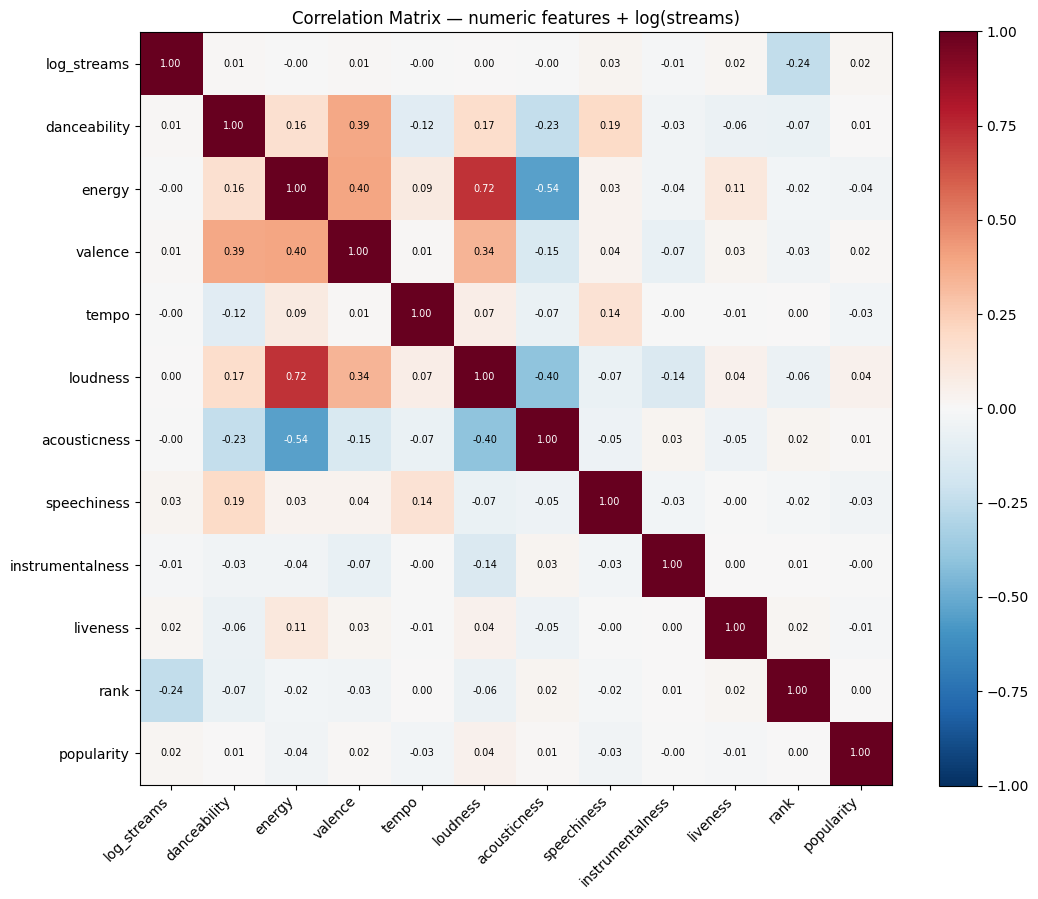


Correlations with log(streams) (sorted):
rank               -0.244661
speechiness         0.025581
popularity          0.021998
liveness            0.019113
instrumentalness   -0.011688
danceability        0.009924
valence             0.009347
acousticness       -0.004312
tempo              -0.003895
loudness            0.002207
energy             -0.000947


In [ ]:
corr_df = con.execute("""
    SELECT
        LN(TRY_CAST(streams        AS DOUBLE)) AS log_streams,
        TRY_CAST(af_danceability   AS DOUBLE)  AS danceability,
        TRY_CAST(af_energy         AS DOUBLE)  AS energy,
        TRY_CAST(af_valence        AS DOUBLE)  AS valence,
        TRY_CAST(af_tempo          AS DOUBLE)  AS tempo,
        TRY_CAST(af_loudness       AS DOUBLE)  AS loudness,
        TRY_CAST(af_acousticness   AS DOUBLE)  AS acousticness,
        TRY_CAST(af_speechiness    AS DOUBLE)  AS speechiness,
        TRY_CAST(af_instrumentalness AS DOUBLE) AS instrumentalness,
        TRY_CAST(af_liveness       AS DOUBLE)  AS liveness,
        TRY_CAST(rank              AS DOUBLE)  AS rank,
        TRY_CAST(popularity        AS DOUBLE)  AS popularity
    FROM spotify_full
    WHERE streams IS NOT NULL
      AND TRY_CAST(streams AS DOUBLE) > 0
    USING SAMPLE 50000
""").df()

corr = corr_df.dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

ax.set_title("Correlation Matrix — numeric features + log(streams)")
plt.tight_layout()
plt.show()

print("\nCorrelations with log(streams) (sorted):")
print(corr["log_streams"].drop("log_streams").sort_values(key=abs, ascending=False).to_string())


**Interpretation — Correlation Matrix:** The most prominent correlation in the matrix is the strong positive relationship between energy and loudness. This is physically intuitive — acoustically louder productions are generally perceived as higher-energy — and represents the primary multicollinearity concern in the audio feature set. Retaining both features in a linear model may inflate coefficient variance for either variable; one option is to retain only loudness (which has a slightly higher absolute correlation with popularity) or to accept the minor instability knowing that regularization will shrink the redundant coefficient.

Acousticness shows the expected strong negative correlations with both energy and loudness, as acoustic production is by definition quieter and less electronically amplified. Beyond these physically grounded relationships, most other feature pairs show correlations well below 0.5 in absolute value, suggesting that multicollinearity is limited and tractable.

Correlations between individual audio features and log(streams) or popularity are uniformly small (|r| < 0.15 for most pairs). This corroborates the finding from Section 8.3: audio characteristics contribute limited individual predictive power for streaming success, and the model's strongest signals will come from geographic and artist-level contextual features.

**Section 8 Wrap-Up:** The substantive analysis has produced four empirically grounded conclusions that directly shape modeling decisions: (1) geographic context is the dominant structural determinant of stream volume; (2) artist-level chart history shows extreme concentration and is expected to be the strongest predictor of cross-border success; (3) the prediction target is a rare-event, imbalanced binary outcome; and (4) the energy–loudness pair is the primary multicollinearity concern requiring attention in the preprocessing pipeline. The notebook now turns to formalising these insights into a preprocessing pipeline and a modeling baseline.

## 8.2 Correlation with Binary Target

Point-biserial correlation of all numeric features with the binary international success target.

In [ ]:
# ── 8.2 Correlation with binary target ─────────────────────────────────────
from scipy.stats import pointbiserialr

# Merge all numeric features with target
corr_features = audio_target.merge(
    spread[["track_id", "countries_reached"]], on="track_id", how="left"
)

target_col = "is_international"
corr_features = corr_features.merge(spread[["track_id", "is_international"]], on="track_id", how="left")

numeric_cols = audio_cols  # from section 6.1

print("═" * 55)
print("  POINT-BISERIAL CORRELATION WITH BINARY TARGET")
print(f"  Target: is_international (>= {TARGET_THRESHOLD} countries)")
print("═" * 55)

pb_results = []
for col in numeric_cols:
    clean = corr_features[[col, target_col]].dropna()
    if len(clean) > 0:
        r, p = pointbiserialr(clean[target_col], clean[col])
        pb_results.append({"feature": col, "correlation": round(r, 4), "p_value": round(p, 6)})

pb_df = pd.DataFrame(pb_results).sort_values("correlation", key=abs, ascending=False)
display(pb_df)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if c >= 0 else "tomato" for c in pb_df["correlation"]]
ax.barh(pb_df["feature"][::-1], pb_df["correlation"][::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Point-Biserial Correlation with International Success (>= {TARGET_THRESHOLD} countries)")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

**Findings — Correlation with Binary Target:**

*To be completed after running.*

## 8.3 VIF Analysis

Variance Inflation Factor for planned numeric features to quantify multicollinearity.

In [ ]:
# ── 8.3 VIF Analysis ───────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = audio_per_track[audio_cols].dropna()

# Standardize before VIF
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
vif_scaled = pd.DataFrame(scaler.fit_transform(vif_data), columns=audio_cols)

vif_results = []
for i, col in enumerate(audio_cols):
    vif_results.append({"feature": col, "VIF": round(variance_inflation_factor(vif_scaled.values, i), 2)})

vif_df = pd.DataFrame(vif_results).sort_values("VIF", ascending=False)

print("═" * 45)
print("  VARIANCE INFLATION FACTOR")
print("═" * 45)
display(vif_df)

print("\nRule of thumb: VIF > 5 indicates concerning multicollinearity, VIF > 10 is severe.")
high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\n⚠️  Features with VIF > 5: {', '.join(high_vif['feature'].tolist())}")
else:
    print("\n✅  No features exceed VIF = 5.")

**Findings — VIF Analysis:**

*To be completed after running.*

---
# Part IX — Key Findings and Transition to Modeling

## 9.1 Executive Summary of Key Findings

*To be written after all analyses are complete. Summarize 5–7 key findings that directly inform modeling decisions.*

## 9.2 Target Variable Decision

*State the chosen threshold, the resulting class balance, and the justification.*

## 9.3 Feature Relevance Ranking

*Rank features by observed signal strength from the bivariate analyses in Part VI.*

## 9.4 Geographic and Cultural Hypotheses — Confirmed or Refuted?

*Summarize whether language, cultural distance, and continent effects were validated in Part VII.*

## 9.5 Data Quality Decisions Summary

*Consolidate all keep/drop/impute decisions with rationale.*

## 9.6 Risks, Limitations, and Known Biases

*Document: survivorship bias (only charting songs), temporal non-stationarity, missing cultural distance for some countries, 2017–2021 time window.*

## 9.7 Transition to Modeling Notebook

*Explicit handoff: what the modeling notebook will receive (feature-engineered dataset), what target variable and train/test split will be used, and which models will be compared.*

---

**End of EDA notebook.** All modeling (logistic regression baseline, random forest, XGBoost, hyperparameter tuning, SHAP analysis) will be conducted in the separate modeling notebook using the feature-engineered dataset constructed from the decisions documented here.